model building

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets
from sklearn import cluster
import sklearn
import seaborn as sns
from sklearn import decomposition
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn import svm
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from scipy.stats import boxcox
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [192]:
# allow us to see all columns
pd.set_option('display.max_columns', None)

# Prep

In [193]:
df_5yr = pd.read_csv("df_absolute5yr5yrNEXT.csv")
df_5yr.sample(5)

,Year,Country Name,Country Code,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),Central Government Debt (Percent of GDP),InfraSpend,"Mining, manufacturing and construction/Total function",Transport/Total function,Communication/Total function,Fuel and energy/Total function,Housing and community amenities/Total function,Health/Total function,Education/Total function,Public order and safety/Total function,RandD Economic affairs/Total function,FDI % of GDP,Overall Score,Property Rights,Government Integrity,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,Real interest rate (%) 1Yr % Change,Population ages 15-64 (% of total population) 1Yr % Change,GDP (current US$) 1Yr % Change,Net migration 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 1Yr % Change",Public Social spending % of GDP 1Yr % Change,Urban population (% of total population) 1Yr % Change,"Labor force, total 1Yr % Change",Imports of goods and services (% of GDP) 1Yr % Change,Tax revenue (% of GDP) 1Yr % Change,"Current account balance (BoP, current US$) 1Yr % Change","Inflation, consumer prices (annual %) 1Yr % Change",Profit tax (% of commercial profits) 1Yr % Change,Exports of goods and services (% of GDP) 1Yr % Change,Population growth (annual %) 1Yr % Change,Central Government Debt (Percent of GDP) 1Yr % Change,Categorized/Total function 1Yr % Change,"Mining, manufacturing and construction/Total function 1Yr % Change",Transport/Total function 1Yr % Change,Communication/Total function 1Yr % Change,Fuel and energy/Total function 1Yr % Change,Housing and community amenities/Total function 1Yr % Change,Health/Total function 1Yr % Change,Education/Total function 1Yr % Change,Public order and safety/Total function 1Yr % Change,RandD Economic affairs/Total function 1Yr % Change,FDI % of GDP 1Yr % Change,Overall Score 1Yr % Change,Property Rights 1Yr % Change,Government Integrity 1Yr % Change,Tax Burden 1Yr % Change,Government Spending 1Yr % Change,Business Freedom 1Yr % Change,Labor Freedom 1Yr % Change,Monetary Freedom 1Yr % Change,Trade Freedom 1Yr % Change,Investment Freedom 1Yr % Change,Financial Freedom 1Yr % Change,Total Function % of GDP 1Yr % Change,Real interest rate (%) Next 1Yr % Change,Population ages 15-64 (% of total population) Next 1Yr % Change,GDP (current US$) Next 1Yr % Change,Net migration Next 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 1Yr % Change",Public Social spending % of GDP Next 1Yr % Change,Urban population (% of total population) Next 1Yr % Change,"Labor force, total Next 1Yr % Change",Imports of goods and services (% of GDP) Next 1Yr % Change,Tax revenue (% of GDP) Next 1Yr % Change,"Current account balance (BoP, current US$) Next 1Yr % Change","Inflation, consumer prices (annual %) Next 1Yr % Change",Profit tax (% of commercial profits) Next 1Yr % Change,Exports of goods and services (% of GDP) Next 1Yr % Change,Population growth (annual %) Next 1Yr % Change,Central Government Debt (Percent of GDP) Next 1Yr % Change,Categorized/Total function Next 1Yr % Change,"Mining, manufacturing and construction/Total function Next 1Yr % Change",Transport/Total function Next 1Yr % Change,Communication/Total function Next 1Yr % Change,Fuel and energy/Total function Next 1Yr % Change,Housing and community amenities/Total function Next 1Yr % Change,Health/Total function Next 1Yr

In [194]:
df_5yr = df_5yr[~df_5yr["Country Name"].isin(["China", "United States"])]


In [195]:
df = df_5yr

In [196]:
df.describe()


,Year,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),Central Government Debt (Percent of GDP),InfraSpend,"Mining, manufacturing and construction/Total function",Transport/Total function,Communication/Total function,Fuel and energy/Total function,Housing and community amenities/Total function,Health/Total function,Education/Total function,Public order and safety/Total function,RandD Economic affairs/Total function,FDI % of GDP,Overall Score,Property Rights,Government Integrity,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,Real interest rate (%) 1Yr % Change,Population ages 15-64 (% of total population) 1Yr % Change,GDP (current US$) 1Yr % Change,Net migration 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 1Yr % Change",Public Social spending % of GDP 1Yr % Change,Urban population (% of total population) 1Yr % Change,"Labor force, total 1Yr % Change",Imports of goods and services (% of GDP) 1Yr % Change,Tax revenue (% of GDP) 1Yr % Change,"Current account balance (BoP, current US$) 1Yr % Change","Inflation, consumer prices (annual %) 1Yr % Change",Profit tax (% of commercial profits) 1Yr % Change,Exports of goods and services (% of GDP) 1Yr % Change,Population growth (annual %) 1Yr % Change,Central Government Debt (Percent of GDP) 1Yr % Change,Categorized/Total function 1Yr % Change,"Mining, manufacturing and construction/Total function 1Yr % Change",Transport/Total function 1Yr % Change,Communication/Total function 1Yr % Change,Fuel and energy/Total function 1Yr % Change,Housing and community amenities/Total function 1Yr % Change,Health/Total function 1Yr % Change,Education/Total function 1Yr % Change,Public order and safety/Total function 1Yr % Change,RandD Economic affairs/Total function 1Yr % Change,FDI % of GDP 1Yr % Change,Overall Score 1Yr % Change,Property Rights 1Yr % Change,Government Integrity 1Yr % Change,Tax Burden 1Yr % Change,Government Spending 1Yr % Change,Business Freedom 1Yr % Change,Labor Freedom 1Yr % Change,Monetary Freedom 1Yr % Change,Trade Freedom 1Yr % Change,Investment Freedom 1Yr % Change,Financial Freedom 1Yr % Change,Total Function % of GDP 1Yr % Change,Real interest rate (%) Next 1Yr % Change,Population ages 15-64 (% of total population) Next 1Yr % Change,GDP (current US$) Next 1Yr % Change,Net migration Next 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 1Yr % Change",Public Social spending % of GDP Next 1Yr % Change,Urban population (% of total population) Next 1Yr % Change,"Labor force, total Next 1Yr % Change",Imports of goods and services (% of GDP) Next 1Yr % Change,Tax revenue (% of GDP) Next 1Yr % Change,"Current account balance (BoP, current US$) Next 1Yr % Change","Inflation, consumer prices (annual %) Next 1Yr % Change",Profit tax (% of commercial profits) Next 1Yr % Change,Exports of goods and services (% of GDP) Next 1Yr % Change,Population growth (annual %) Next 1Yr % Change,Central Government Debt (Percent of GDP) Next 1Yr % Change,Categorized/Total function Next 1Yr % Change,"Mining, manufacturing and construction/Total function Next 1Yr % Change",Transport/Total function Next 1Yr % Change,Communication/Total function Next 1Yr % Change,Fuel and energy/Total function Next 1Yr % Change,Housing and community amenities/Total function Next 1Yr % Change,Health/Total function Next 1Yr % Change,Education/Total 

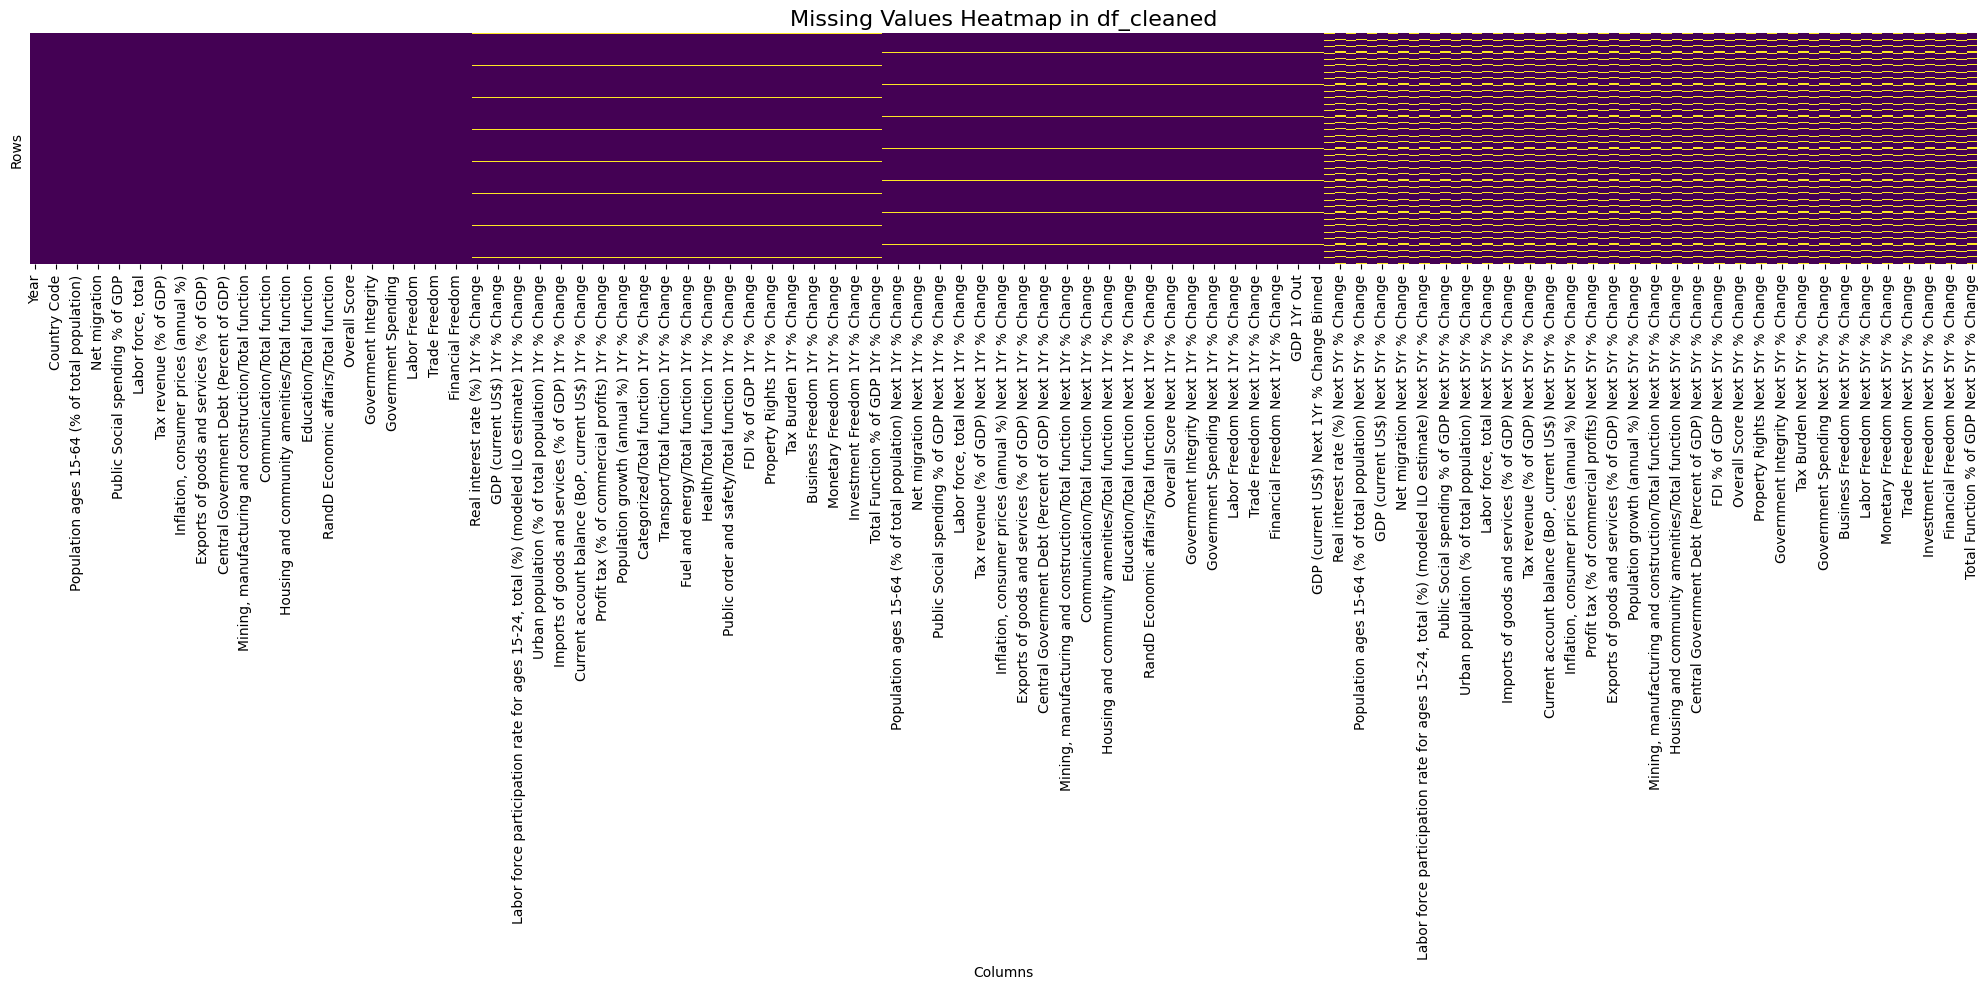

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(20, 10))

# Heatmap of missing values
sns.heatmap(df.isna(), 
            cbar=False, 
            cmap='viridis', 
            yticklabels=False)

plt.title('Missing Values Heatmap in df_cleaned', fontsize=16)
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()


In [198]:
### maybe add country if i want a less general model. 
from sklearn.preprocessing import LabelEncoder

# Copy df so original isn't modified
df = df.copy()

# Initialize the encoder
le = LabelEncoder()

# Fit and transform
df['Country Name'] = le.fit_transform(df['Country Name'])

# Optionally drop the old 'Country Name' if you don't need it
# df_encoded.drop(columns=['Country Name'], inplace=True)


# but add the column below if I want too

In [199]:
df

,Year,Country Name,Country Code,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),Central Government Debt (Percent of GDP),InfraSpend,"Mining, manufacturing and construction/Total function",Transport/Total function,Communication/Total function,Fuel and energy/Total function,Housing and community amenities/Total function,Health/Total function,Education/Total function,Public order and safety/Total function,RandD Economic affairs/Total function,FDI % of GDP,Overall Score,Property Rights,Government Integrity,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,Real interest rate (%) 1Yr % Change,Population ages 15-64 (% of total population) 1Yr % Change,GDP (current US$) 1Yr % Change,Net migration 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 1Yr % Change",Public Social spending % of GDP 1Yr % Change,Urban population (% of total population) 1Yr % Change,"Labor force, total 1Yr % Change",Imports of goods and services (% of GDP) 1Yr % Change,Tax revenue (% of GDP) 1Yr % Change,"Current account balance (BoP, current US$) 1Yr % Change","Inflation, consumer prices (annual %) 1Yr % Change",Profit tax (% of commercial profits) 1Yr % Change,Exports of goods and services (% of GDP) 1Yr % Change,Population growth (annual %) 1Yr % Change,Central Government Debt (Percent of GDP) 1Yr % Change,Categorized/Total function 1Yr % Change,"Mining, manufacturing and construction/Total function 1Yr % Change",Transport/Total function 1Yr % Change,Communication/Total function 1Yr % Change,Fuel and energy/Total function 1Yr % Change,Housing and community amenities/Total function 1Yr % Change,Health/Total function 1Yr % Change,Education/Total function 1Yr % Change,Public order and safety/Total function 1Yr % Change,RandD Economic affairs/Total function 1Yr % Change,FDI % of GDP 1Yr % Change,Overall Score 1Yr % Change,Property Rights 1Yr % Change,Government Integrity 1Yr % Change,Tax Burden 1Yr % Change,Government Spending 1Yr % Change,Business Freedom 1Yr % Change,Labor Freedom 1Yr % Change,Monetary Freedom 1Yr % Change,Trade Freedom 1Yr % Change,Investment Freedom 1Yr % Change,Financial Freedom 1Yr % Change,Total Function % of GDP 1Yr % Change,Real interest rate (%) Next 1Yr % Change,Population ages 15-64 (% of total population) Next 1Yr % Change,GDP (current US$) Next 1Yr % Change,Net migration Next 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 1Yr % Change",Public Social spending % of GDP Next 1Yr % Change,Urban population (% of total population) Next 1Yr % Change,"Labor force, total Next 1Yr % Change",Imports of goods and services (% of GDP) Next 1Yr % Change,Tax revenue (% of GDP) Next 1Yr % Change,"Current account balance (BoP, current US$) Next 1Yr % Change","Inflation, consumer prices (annual %) Next 1Yr % Change",Profit tax (% of commercial profits) Next 1Yr % Change,Exports of goods and services (% of GDP) Next 1Yr % Change,Population growth (annual %) Next 1Yr % Change,Central Government Debt (Percent of GDP) Next 1Yr % Change,Categorized/Total function Next 1Yr % Change,"Mining, manufacturing and construction/Total function Next 1Yr % Change",Transport/Total function Next 1Yr % Change,Communication/Total function Next 1Yr % Change,Fuel and energy/Total function Next 1Yr % Change,Housing and community amenities/Total function Next 1Yr % Change,Health/Total function Next 1Yr

In [200]:
df.describe()

,Year,Country Name,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),Central Government Debt (Percent of GDP),InfraSpend,"Mining, manufacturing and construction/Total function",Transport/Total function,Communication/Total function,Fuel and energy/Total function,Housing and community amenities/Total function,Health/Total function,Education/Total function,Public order and safety/Total function,RandD Economic affairs/Total function,FDI % of GDP,Overall Score,Property Rights,Government Integrity,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,Real interest rate (%) 1Yr % Change,Population ages 15-64 (% of total population) 1Yr % Change,GDP (current US$) 1Yr % Change,Net migration 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 1Yr % Change",Public Social spending % of GDP 1Yr % Change,Urban population (% of total population) 1Yr % Change,"Labor force, total 1Yr % Change",Imports of goods and services (% of GDP) 1Yr % Change,Tax revenue (% of GDP) 1Yr % Change,"Current account balance (BoP, current US$) 1Yr % Change","Inflation, consumer prices (annual %) 1Yr % Change",Profit tax (% of commercial profits) 1Yr % Change,Exports of goods and services (% of GDP) 1Yr % Change,Population growth (annual %) 1Yr % Change,Central Government Debt (Percent of GDP) 1Yr % Change,Categorized/Total function 1Yr % Change,"Mining, manufacturing and construction/Total function 1Yr % Change",Transport/Total function 1Yr % Change,Communication/Total function 1Yr % Change,Fuel and energy/Total function 1Yr % Change,Housing and community amenities/Total function 1Yr % Change,Health/Total function 1Yr % Change,Education/Total function 1Yr % Change,Public order and safety/Total function 1Yr % Change,RandD Economic affairs/Total function 1Yr % Change,FDI % of GDP 1Yr % Change,Overall Score 1Yr % Change,Property Rights 1Yr % Change,Government Integrity 1Yr % Change,Tax Burden 1Yr % Change,Government Spending 1Yr % Change,Business Freedom 1Yr % Change,Labor Freedom 1Yr % Change,Monetary Freedom 1Yr % Change,Trade Freedom 1Yr % Change,Investment Freedom 1Yr % Change,Financial Freedom 1Yr % Change,Total Function % of GDP 1Yr % Change,Real interest rate (%) Next 1Yr % Change,Population ages 15-64 (% of total population) Next 1Yr % Change,GDP (current US$) Next 1Yr % Change,Net migration Next 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 1Yr % Change",Public Social spending % of GDP Next 1Yr % Change,Urban population (% of total population) Next 1Yr % Change,"Labor force, total Next 1Yr % Change",Imports of goods and services (% of GDP) Next 1Yr % Change,Tax revenue (% of GDP) Next 1Yr % Change,"Current account balance (BoP, current US$) Next 1Yr % Change","Inflation, consumer prices (annual %) Next 1Yr % Change",Profit tax (% of commercial profits) Next 1Yr % Change,Exports of goods and services (% of GDP) Next 1Yr % Change,Population growth (annual %) Next 1Yr % Change,Central Government Debt (Percent of GDP) Next 1Yr % Change,Categorized/Total function Next 1Yr % Change,"Mining, manufacturing and construction/Total function Next 1Yr % Change",Transport/Total function Next 1Yr % Change,Communication/Total function Next 1Yr % Change,Fuel and energy/Total function Next 1Yr % Change,Housing and community amenities/Total function Next 1Yr % Change,Health/Total function Next 1Yr % Change,Edu

I checked for VIF in all the other variables in the other ipynb. The regular variables have a fair share of it... below doesnt. and 5yr% change doesnt either 

In [201]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# List of columns (remove any non-numeric like 'Region' if it's not encoded)
vif_columns = [
    'Real interest rate (%) Next 5Yr % Change',
    'Population ages 15-64 (% of total population) Next 5Yr % Change',
    'GDP (current US$) Next 5Yr % Change',
    'Net migration Next 5Yr % Change',
    'Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 5Yr % Change',
    'Public Social spending % of GDP Next 5Yr % Change',
    'Urban population (% of total population) Next 5Yr % Change',
    'Labor force, total Next 5Yr % Change',
    'Imports of goods and services (% of GDP) Next 5Yr % Change',
    'Tax revenue (% of GDP) Next 5Yr % Change',
    'Current account balance (BoP, current US$) Next 5Yr % Change',
    'Inflation, consumer prices (annual %) Next 5Yr % Change',
    'Profit tax (% of commercial profits) Next 5Yr % Change',
    'Exports of goods and services (% of GDP) Next 5Yr % Change',
    'Population growth (annual %) Next 5Yr % Change',
    'Mining, manufacturing and construction/Total function Next 5Yr % Change',
    'Housing and community amenities/Total function Next 5Yr % Change',
    'Central Government Debt (Percent of GDP) Next 5Yr % Change',
    'FDI % of GDP Next 5Yr % Change',
    'Overall Score Next 5Yr % Change',
    'Property Rights Next 5Yr % Change',
    'Government Integrity Next 5Yr % Change',
    'Tax Burden Next 5Yr % Change',
    'Government Spending Next 5Yr % Change',
    'Business Freedom Next 5Yr % Change',
    'Labor Freedom Next 5Yr % Change',
    'Monetary Freedom Next 5Yr % Change',
    'Trade Freedom Next 5Yr % Change',
    'Investment Freedom Next 5Yr % Change',
    'Financial Freedom Next 5Yr % Change',
    'Total Function % of GDP Next 5Yr % Change'
    # 'Region Next 5Yr % Change'  # remove if it's not numeric
]

# Select and clean the DataFrame
df_vif = df[vif_columns].copy()

# Remove any infinite or extremely large/small values
df_vif.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with any remaining NaN
df_vif.dropna(inplace=True)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_vif)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = df_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

# Display
print(vif_data.sort_values(by='VIF', ascending=False))


                                             Variable       VIF
19                    Overall Score Next 5Yr % Change  3.383361
13  Exports of goods and services (% of GDP) Next ...  2.272001
8   Imports of goods and services (% of GDP) Next ...  2.156046
7                Labor force, total Next 5Yr % Change  2.078253
1   Population ages 15-64 (% of total population) ...  1.980914
4   Labor force participation rate for ages 15-24,...  1.532844
29                Financial Freedom Next 5Yr % Change  1.517611
2                 GDP (current US$) Next 5Yr % Change  1.491173
27                    Trade Freedom Next 5Yr % Change  1.435334
20                  Property Rights Next 5Yr % Change  1.425773
22                       Tax Burden Next 5Yr % Change  1.412689
26                 Monetary Freedom Next 5Yr % Change  1.363762
28               Investment Freedom Next 5Yr % Change  1.333469
5   Public Social spending % of GDP Next 5Yr % Change  1.326387
21             Government Integrity Next

In [202]:
df.describe()

,Year,Country Name,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),Central Government Debt (Percent of GDP),InfraSpend,"Mining, manufacturing and construction/Total function",Transport/Total function,Communication/Total function,Fuel and energy/Total function,Housing and community amenities/Total function,Health/Total function,Education/Total function,Public order and safety/Total function,RandD Economic affairs/Total function,FDI % of GDP,Overall Score,Property Rights,Government Integrity,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,Real interest rate (%) 1Yr % Change,Population ages 15-64 (% of total population) 1Yr % Change,GDP (current US$) 1Yr % Change,Net migration 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 1Yr % Change",Public Social spending % of GDP 1Yr % Change,Urban population (% of total population) 1Yr % Change,"Labor force, total 1Yr % Change",Imports of goods and services (% of GDP) 1Yr % Change,Tax revenue (% of GDP) 1Yr % Change,"Current account balance (BoP, current US$) 1Yr % Change","Inflation, consumer prices (annual %) 1Yr % Change",Profit tax (% of commercial profits) 1Yr % Change,Exports of goods and services (% of GDP) 1Yr % Change,Population growth (annual %) 1Yr % Change,Central Government Debt (Percent of GDP) 1Yr % Change,Categorized/Total function 1Yr % Change,"Mining, manufacturing and construction/Total function 1Yr % Change",Transport/Total function 1Yr % Change,Communication/Total function 1Yr % Change,Fuel and energy/Total function 1Yr % Change,Housing and community amenities/Total function 1Yr % Change,Health/Total function 1Yr % Change,Education/Total function 1Yr % Change,Public order and safety/Total function 1Yr % Change,RandD Economic affairs/Total function 1Yr % Change,FDI % of GDP 1Yr % Change,Overall Score 1Yr % Change,Property Rights 1Yr % Change,Government Integrity 1Yr % Change,Tax Burden 1Yr % Change,Government Spending 1Yr % Change,Business Freedom 1Yr % Change,Labor Freedom 1Yr % Change,Monetary Freedom 1Yr % Change,Trade Freedom 1Yr % Change,Investment Freedom 1Yr % Change,Financial Freedom 1Yr % Change,Total Function % of GDP 1Yr % Change,Real interest rate (%) Next 1Yr % Change,Population ages 15-64 (% of total population) Next 1Yr % Change,GDP (current US$) Next 1Yr % Change,Net migration Next 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 1Yr % Change",Public Social spending % of GDP Next 1Yr % Change,Urban population (% of total population) Next 1Yr % Change,"Labor force, total Next 1Yr % Change",Imports of goods and services (% of GDP) Next 1Yr % Change,Tax revenue (% of GDP) Next 1Yr % Change,"Current account balance (BoP, current US$) Next 1Yr % Change","Inflation, consumer prices (annual %) Next 1Yr % Change",Profit tax (% of commercial profits) Next 1Yr % Change,Exports of goods and services (% of GDP) Next 1Yr % Change,Population growth (annual %) Next 1Yr % Change,Central Government Debt (Percent of GDP) Next 1Yr % Change,Categorized/Total function Next 1Yr % Change,"Mining, manufacturing and construction/Total function Next 1Yr % Change",Transport/Total function Next 1Yr % Change,Communication/Total function Next 1Yr % Change,Fuel and energy/Total function Next 1Yr % Change,Housing and community amenities/Total function Next 1Yr % Change,Health/Total function Next 1Yr % Change,Edu

In [203]:
import pandas as pd

# Assuming df_cleaned is the cleaned dataframe containing 'Country Name', 'Year', and 'GDP (current US$)'

# Calculate the variability (Standard Deviation or Coefficient of Variation) for each country
# Group by Country Name and calculate the standard deviation of GDP across years
country_variability = df.groupby('Country Name')['GDP (current US$)'].std()

# Optionally, calculate Coefficient of Variation (CV) instead of SD, to compare variability relative to the mean
# country_variability_cv = df_cleaned.groupby('Country Name').apply(lambda x: x.std() / x.mean())

# Define a threshold for splitting into high and low variability
# You can use the median, mean, or other percentile for this
threshold = country_variability.median()  # You can adjust this threshold as needed

# Filter countries with higher variability
high_variability_countries = country_variability[country_variability > threshold].index
low_variability_countries = country_variability[country_variability <= threshold].index

# Filter the original dataframe into more variable and less variable dataframes
df_high = df[df['Country Name'].isin(high_variability_countries)]
df_low = df[df['Country Name'].isin(low_variability_countries)]

# Displaying the split datasets
print(f"High Variability Dataset: {df_high.shape}")
print(f"Low Variability Dataset: {df_low.shape}")


High Variability Dataset: (522, 185)
Low Variability Dataset: (522, 185)


In [204]:
import pandas as pd

# Assuming your DataFrame is called df
df['GDP_Next5Yr_Above20'] = (df['GDP (current US$) Next 5Yr % Change'] > 20).astype(int)


In [205]:
df['FDI % of GDP'].describe()

count    1044.000000
mean        4.931527
std        18.495583
min      -360.353363
25%         1.226746
50%         2.802520
75%         5.065447
max       252.919905
Name: FDI % of GDP, dtype: float64

In [206]:
# Assuming your DataFrame is called df
df['FDI_Next1Yr_Above20'] = (df['FDI 1Yr Out'] > 2.819 ).astype(int)

## TESTING MODELS and COMBINATIONS OF VARIABLES AND TARGETS

### Attempts

LEAKAGE only looking for relationships (cant use to predict) - splitting 0.2 - 0.8..  Features were only 5yr% change vars.: Included Year 

Target = GDP 5yr% change. Gradient Boost got 82% r2 XG 81% r2. 5 vars had corr with the residuals. year, tax burden, pop 15-64, gov debt, labor force were all important. 

Taget = GDP NEXT 5yr% change. GB got 76% XG got 75% r2. ^ sames important vars. 


Finally, I added the regular absolute variables... which makes sense because the model right now is not understanding that larger countries may change different based on pop levels, debt severity etc...
I choose the 'absolute variables' to add to the model based on corr with GDP NExt 5yr % change. 

1yr Next change 
⚡ XGBoost Regression Results:
Mean Squared Error (MSE): 80.2414
R² Score: -0.2721

Predicting just the 3 year future GDP... 
⚡ XGBoost Regression Results:
Mean Squared Error (MSE): 50534110218055478935552.0000
R² Score: 0.9636
GDP, Labor force, labor force 5 yr change. The issue is its still like a billion off. is it really good? i guess we can see influecial variables.

Predicting Next 3 % change binned GOOD Results but its binned 25 percentile. GOOD! I couldnt replicate it.
⚡ XGBoost Classification Results:
Accuracy: 0.3333

binned high variable GDP  GOOD!
⚡ XGBoost Classification Results:
Accuracy: 0.3889
binned low variability GDP 
⚡ XGBoost Classification Results:
Accuracy: 0.2222

3 yr predicting - high variable GDP with NExt  5 yr % change GDP 
Bad results
1 yr predicting - 1 yr next gdp got bad results 

1 yr change GDP and training and test are different years has decent result. This is understading what is influencing what at times. its not looking into the future or using a lag. GOOD!
⚡ XGBoost Regression Results:
Mean Squared Error (MSE): 75.1301
R² Score: 0.2975
and 40% r with Gradient boost. 
2 yr same thing. bad result

FDI % GDP split by year. 3yr look. same 3 yrs. answers whats influencing the 2 year shift in FDI GOOD! Cant get the same result.
⚡ XGBoost Regression Results:
Mean Squared Error (MSE): 1328.4512
R² Score: 0.0627
1 yr shift same 1 yr bad results

FDI CHAnge next 1 yr. from 2016 trainging 2020. and testing 2022 GOOD! I couldnt get this result again. I probably had leaking the first time. 
🌳 Decision Tree Regression Results:
Mean Squared Error (MSE): 313620.5126
R² Score: 0.1041

tried the same window above with GDP 1 yr NExt and got slighlt less negative. 

SO far other than the "Leaked models" the non-leaked GOOD models have mediocre results. We can look at variable significance. Possibly a leaked model showing the influence of variables is helpful enough for making an index. 


Below are just columns I had selected previously.

X_columns = [
    'Year',# possibly want to take it out but i think we need it so it adds more importance to values closer to the year.
    #'GDP (current US$) 5Yr % Change', # made it worse by 2%, also no correlation in matrix
    #'Real interest rate (%) 5Yr % Change', 
    'Population ages 15-64 (% of total population) 5Yr % Change',
    #'Net migration 5Yr % Change',
    'Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change', # keep bc has high model importance and kinda ok corr *
    'Public Social spending % of GDP 5Yr % Change', # same as above *
    'Urban population (% of total population) 5Yr % Change', # good corr and high model importance 
    #'Labor force, total 5Yr % Change', # low corr and no model importance 
    'Imports of goods and services (% of GDP) 5Yr % Change', # some importance and little corr *
    'Tax revenue (% of GDP) 5Yr % Change', # 0 corr but high model importance *
    'Current account balance (BoP, current US$) 5Yr % Change', # smallll corr, medium relevance for model *
    'Inflation, consumer prices (annual %) 5Yr % Change', # no corr but has significance in shap *
    #'Profit tax (% of commercial profits) 5Yr % Change', # i think absolute profit tax is more important, no corr, low importance, 
    'Exports of goods and services (% of GDP) 5Yr % Change', # has ok corr but no significance, werid one *
    'Population growth (annual %) 5Yr % Change', # weird how this has no impact... take it out tho, no corr **
    'Mining, manufacturing and construction/Total function 5Yr % Change', # no corr , but medium impact in both
    #'Housing and community amenities/Total function 5Yr % Change', # no corr, no signi
    'Central Government Debt (Percent of GDP) 5Yr % Change', # no corr, above medium signifi
    'FDI % of GDP 5Yr % Change', # little lower than medium signif, no corr, prob should tak it out *
    'Overall Score 5Yr % Change', # good everything
    #'Property Rights 5Yr % Change', # bad all, kinda surprising 
    'Government Integrity 5Yr % Change', # small corr, little relevence *
    'Tax Burden 5Yr % Change', # no corr, medium signif in both
    #'Government Spending 5Yr % Change', # bad all 
    'Business Freedom 5Yr % Change', # good corr, good sig in the one 
    #'Labor Freedom 5Yr % Change', # badd 
    'Monetary Freedom 5Yr % Change', # highest corrrrrrrrrrr , top 5 relevanve
    'Trade Freedom 5Yr % Change', # great corr , sig in shap and below medium in the other
    'Investment Freedom 5Yr % Change', # good all 
    'Financial Freedom 5Yr % Change', # bad corr , medium in one and low in the other **
    'Total Function % of GDP 5Yr % Change', # good all around top 5 corrrr
    'Country Name' # high sig in both
]


In [207]:

# Define feature columns (X) and target column (y)
X_columns = [
    #'Year',# possibly want to take it out but i think we need it so it adds more importance to values closer to the year.
    #'GDP (current US$) 5Yr % Change', # made it worse by 2%, also no correlation in matrix
    #'Real interest rate (%) 5Yr % Change', 
    'Population ages 15-64 (% of total population) 5Yr % Change',
    'Net migration 5Yr % Change',
    'Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change', # keep bc has high model importance and kinda ok corr *
    #'Public Social spending % of GDP 5Yr % Change', # same as above *
    #'Urban population (% of total population) 5Yr % Change', # good corr and high model importance 
    #'Labor force, total 5Yr % Change', # low corr and no model importance 
    #'Imports of goods and services (% of GDP) 5Yr % Change', # some importance and little corr *
    #'Tax revenue (% of GDP) 5Yr % Change', # 0 corr but high model importance *
    #'Current account balance (BoP, current US$) 5Yr % Change', # smallll corr, medium relevance for model *
    #'Inflation, consumer prices (annual %) 5Yr % Change', # no corr but has significance in shap *
    #'Profit tax (% of commercial profits) 5Yr % Change', # i think absolute profit tax is more important, no corr, low importance, 
    'Exports of goods and services (% of GDP) 5Yr % Change', # has ok corr but no significance, werid one *
    #'Population growth (annual %) 5Yr % Change', # weird how this has no impact... take it out tho, no corr **
    #'Mining, manufacturing and construction/Total function 5Yr % Change', # no corr , but medium impact in both
    #'Housing and community amenities/Total function 5Yr % Change', # no corr, no signi
    'Central Government Debt (Percent of GDP) 5Yr % Change', # no corr, above medium signifi
    #'FDI % of GDP 5Yr % Change', # little lower than medium signif, no corr, prob should tak it out *
    #'Overall Score 5Yr % Change', # good everything
    #'Property Rights 5Yr % Change', # bad all, kinda surprising 
    'Government Integrity 5Yr % Change', # small corr, little relevence *
    'Tax Burden 5Yr % Change', # no corr, medium signif in both
    #'Government Spending 5Yr % Change', # bad all 
    #'Business Freedom 5Yr % Change', # good corr, good sig in the one 
    'Labor Freedom 5Yr % Change', # badd 
    'Monetary Freedom 5Yr % Change', # highest corrrrrrrrrrr , top 5 relevanve
    'Trade Freedom 5Yr % Change', # great corr , sig in shap and below medium in the other
    #'Investment Freedom 5Yr % Change', # good all 
    #'Financial Freedom 5Yr % Change', # bad corr , medium in one and low in the other **
    #'Total Function % of GDP 5Yr % Change', # good all around top 5 corrrr
    #'Country Name', # high sig in both
    #"GDP (current US$)",# kinda
    'Population ages 15-64 (% of total population)',
    "Net migration",
    "Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",
    "Public Social spending % of GDP",
    "Urban population (% of total population)",
    "Labor force, total",
    #"Tax revenue (% of GDP)",# kinda
    #"Current account balance (BoP, current US$)", # check 
    "Inflation, consumer prices (annual %)",# kinda
    #"Profit tax (% of commercial profits)",
    #"Population growth (annual %)",
    #"Mining, manufacturing and construction/Total function",
    #"Housing and community amenities/Total function", # kinda
    #"Central Government Debt (Percent of GDP)", # big
    "FDI % of GDP", # interesting bc i shouldve include it
    "Overall Score",
    #"Property Rights",
    "Government Integrity",
    #"Tax Burden", # check
    #"Government Spending",# big, why i take it out of the other.. 
    "Business Freedom", # big
    "Labor Freedom", #small
    "Monetary Freedom",
    "Trade Freedom", #bbig
    "Investment Freedom",
    #"Financial Freedom", #interesting
    "Total Function % of GDP",
    "InfraSpend"
]

#y_column = 'FDI % of GDP Next 5Yr % Change'
y_column = 'GDP (current US$) 5Yr % Change'

X = df[X_columns].copy() # if I want to leak the data to only understand relationships.
y = df[y_column].copy()


# Drop rows with NA in X
X = X.dropna()

# Then align y to match X's index
y = y.loc[X.index]


#### SCALING ## only required for linear regression and multi linear
#from sklearn.preprocessing import RobustScaler

# Initialize the RobustScaler
#scaler = RobustScaler()

# Fit and transform only X (not y)
#X_scaled = scaler.fit_transform(X)

# If you want it back as a DataFrame
#X_scaled = pd.DataFrame(X_scaled, columns=X_columns, index=X.index)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42)



I asked chat a lot about data leakage and having the years and Country name in the training. It makes the most sense to have both in because the model needs to understand different countries behave differently and trends over year change. Also the model needs to recognize more recent years have more importance. For a predictive model its good.

In [208]:
# when NEXT year is the target use the code below for splitting
#train_df = df[df['Year'] <= 2017] # when not using NEXT 
#train_df = df[(df['Year'] > 2000) & (df['Year'] <= 2020)] # when using NEXT 

#test_df = df[df['Year'] == 2022]

#X_train = train_df[X_columns]
#y_train = train_df[y_column]

#X_test = test_df[X_columns]
#y_test = test_df[y_column]

#X_train.dropna(inplace=True)
#y_train.dropna(inplace=True)

#X_test.dropna(inplace=True)
#y_test.dropna(inplace=True)



In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1044 entries, 0 to 1072
Columns: 187 entries, Year to FDI_Next1Yr_Above20
dtypes: float64(182), int32(3), int64(1), object(1)
memory usage: 1.5+ MB


In [210]:
df.describe()

,Year,Country Name,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),Central Government Debt (Percent of GDP),InfraSpend,"Mining, manufacturing and construction/Total function",Transport/Total function,Communication/Total function,Fuel and energy/Total function,Housing and community amenities/Total function,Health/Total function,Education/Total function,Public order and safety/Total function,RandD Economic affairs/Total function,FDI % of GDP,Overall Score,Property Rights,Government Integrity,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,Real interest rate (%) 1Yr % Change,Population ages 15-64 (% of total population) 1Yr % Change,GDP (current US$) 1Yr % Change,Net migration 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 1Yr % Change",Public Social spending % of GDP 1Yr % Change,Urban population (% of total population) 1Yr % Change,"Labor force, total 1Yr % Change",Imports of goods and services (% of GDP) 1Yr % Change,Tax revenue (% of GDP) 1Yr % Change,"Current account balance (BoP, current US$) 1Yr % Change","Inflation, consumer prices (annual %) 1Yr % Change",Profit tax (% of commercial profits) 1Yr % Change,Exports of goods and services (% of GDP) 1Yr % Change,Population growth (annual %) 1Yr % Change,Central Government Debt (Percent of GDP) 1Yr % Change,Categorized/Total function 1Yr % Change,"Mining, manufacturing and construction/Total function 1Yr % Change",Transport/Total function 1Yr % Change,Communication/Total function 1Yr % Change,Fuel and energy/Total function 1Yr % Change,Housing and community amenities/Total function 1Yr % Change,Health/Total function 1Yr % Change,Education/Total function 1Yr % Change,Public order and safety/Total function 1Yr % Change,RandD Economic affairs/Total function 1Yr % Change,FDI % of GDP 1Yr % Change,Overall Score 1Yr % Change,Property Rights 1Yr % Change,Government Integrity 1Yr % Change,Tax Burden 1Yr % Change,Government Spending 1Yr % Change,Business Freedom 1Yr % Change,Labor Freedom 1Yr % Change,Monetary Freedom 1Yr % Change,Trade Freedom 1Yr % Change,Investment Freedom 1Yr % Change,Financial Freedom 1Yr % Change,Total Function % of GDP 1Yr % Change,Real interest rate (%) Next 1Yr % Change,Population ages 15-64 (% of total population) Next 1Yr % Change,GDP (current US$) Next 1Yr % Change,Net migration Next 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 1Yr % Change",Public Social spending % of GDP Next 1Yr % Change,Urban population (% of total population) Next 1Yr % Change,"Labor force, total Next 1Yr % Change",Imports of goods and services (% of GDP) Next 1Yr % Change,Tax revenue (% of GDP) Next 1Yr % Change,"Current account balance (BoP, current US$) Next 1Yr % Change","Inflation, consumer prices (annual %) Next 1Yr % Change",Profit tax (% of commercial profits) Next 1Yr % Change,Exports of goods and services (% of GDP) Next 1Yr % Change,Population growth (annual %) Next 1Yr % Change,Central Government Debt (Percent of GDP) Next 1Yr % Change,Categorized/Total function Next 1Yr % Change,"Mining, manufacturing and construction/Total function Next 1Yr % Change",Transport/Total function Next 1Yr % Change,Communication/Total function Next 1Yr % Change,Fuel and energy/Total function Next 1Yr % Change,Housing and community amenities/Total function Next 1Yr % Change,Health/Total function Next 1Yr % Change,Edu

In [211]:
X_train.describe()

,Population ages 15-64 (% of total population) 5Yr % Change,Net migration 5Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change",Exports of goods and services (% of GDP) 5Yr % Change,Central Government Debt (Percent of GDP) 5Yr % Change,Government Integrity 5Yr % Change,Tax Burden 5Yr % Change,Labor Freedom 5Yr % Change,Monetary Freedom 5Yr % Change,Trade Freedom 5Yr % Change,Population ages 15-64 (% of total population),Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,Urban population (% of total population),"Labor force, total","Inflation, consumer prices (annual %)",FDI % of GDP,Overall Score,Government Integrity,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Total Function % of GDP,InfraSpend
count,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,6.910000e+02,691.000000,691.000000,691.000000,6.910000e+02,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000
mean,-0.302765,-103.566479,-2.505171,9.403591,23.694432,5.239397,4.119736,0.484051,3.238915,2.554459,66.565439,6.430759e+04,46.077920,19.531445,76.110603,1.311046e+07,3.418927,5.476802,70.692619,67.905355,78.908683,63.506078,80.938350,82.782055,75.202605,42.458651,0.398716
std,1.977239,2128.221626,9.900505,16.112438,93.803938,23.052897,12.042914,10.980553,27.671310,7.509901,2.376752,1.570606e+05,14.091177,6.097863,11.009350,1.577584e+07,4.965306,22.044643,6.662692,19.938960,9.918369,13.706197,6.022914,5.246323,11.494903,7.873651,0.058876
min,-5.222261,-42300.869565,-40.214889,-35.511065,-74.069958,-47.777778,-44.059406,-42.204301,-22.747748,-30.843373,58.734738,-4.890560e+05,22.996000,4.412000,50.780000,1.694480e+05,-1.735888,-360.353363,50.600000,26.300000,53.700000,31.000000,31.800000,57.400000,50.000000,23.555308,0.235198
25%,-1.674193,-62.137415,-7.871266,-0.647633,-12.879274,-5.000000,-1.591356,-3.775407,-3.887631,-1.005773,65.123119,1.588000e+03,34.081500,15.548500,68.033500,2.440204e+06,1.285710,1.441896,65.700000,49.900000,70.000000,54.000000,78.200000,79.600000,70.000000,36.842094,0.354843
50%,-0.415011,-1.136541,-2.042013,7.531945,7.577909,1.800000,1.773050,0.000000,0.475624,0.930233,66.454708,2.028300e+04,44.001000,19.650000,77.502000,4.980273e+06,2.453965,2.982802,70.500000,71.000000,78.700000,61.400000,81.300000,84.000000,75.000000,42.669271,0.392446
75%,1.083854,81.313683,2.782609,17.438518,30.931254,9.413068,8.332977,2.742687,5.128207,5.651106,67.976796,7.642650e+04,56.880500,23.924500,84.831500,2.283595e+07,3.934581,5.404445,76.000000,86.200000,85.650000,74.150000,84.900000,86.900000,85.000000,48.499007,0.433182
max,4.248359,6521.205357,42.279546,79.393284,1402.945779,260.000000,90.813648,51.732673,557.364341,45.454545,73.281512,1.175283e+06,83.030000,34.876000,98.189000,6.920814e+07,72.308836,252.919905,84.400000,100.000000,100.000000,100.000000,94.300000,92.400000,95.000000,64.873460,0.602712


In [212]:
y_train.describe()

count    691.000000
mean      31.645771
std       39.372260
min      -34.360599
25%        3.314906
50%       22.327044
75%       50.869794
max      218.092800
Name: GDP (current US$) 5Yr % Change, dtype: float64

## BASELINE

In [213]:
# Pull the y and X data from df_cleaned
y_column = df[y_column]
X_columns = df[X_columns]

# Combine them into one DataFrame
combined_df = pd.concat([y_column, X_columns], axis=1)

# Optional: drop rows with any missing values
combined_df = combined_df.dropna()


In [214]:
y_copy = y_column.copy()
y_copy.dropna(inplace=True)


In [215]:
# Assume y_true is your actual GDP 5Yr % Change column
y_true = y_copy

# Baseline prediction: just the mean
baseline_pred = np.full_like(y_true, y_true.mean())

# Now calculate MSE and R²
from sklearn.metrics import mean_squared_error, r2_score

baseline_mse = mean_squared_error(y_true, baseline_pred)
baseline_r2 = r2_score(y_true, baseline_pred)

print(f"Baseline MSE: {baseline_mse}")
print(f"Baseline R2: {baseline_r2}")


Baseline MSE: 1490.2691978352586
Baseline R2: 0.0


gotta beat baseline

In [216]:
import pandas as pd
from linearmodels.iv import IV2SLS
from sklearn.model_selection import train_test_split

This model below wont run sometimes.... 

In [217]:
# Combine them into a single DataFrame for the model
#df_model = df[X_columns + [y_column]].copy()

# Add a constant for the intercept
#df_model = df_model.dropna().copy()  # Drop rows with NA for now to run 2SLS
#df_model['const'] = 1

# Split into train and test sets
#train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)

# === SETUP FOR 2SLS ===
# You need to specify:
# - dependent variable (y)
# - exogenous regressors (not correlated with errors)
# - endogenous regressors (correlated with errors)
# - instruments (used to predict the endogenous variables)

# Replace the following placeholders:
#   - 'y_column': your dependent variable
#   - 'endog_var': one or more endogenous regressors (from X_columns)
#   - 'instr_vars': list of instruments that are not in the regression directly, but help predict endog_var

# Set endogenous and instruments
#y_col = y_column
#endog_var = 'Central Government Debt (Percent of GDP) 5Yr % Change'
#instr_vars = ['FDI % of GDP 5Yr % Change', 'Tax Burden 5Yr % Change']

# Exogenous vars are everything except endog_var and instruments
#exog_vars = [col for col in X_columns if col != endog_var and col not in instr_vars]

# Add constant
#df_model['const'] = 1

# Fit 2SLS
#model = IV2SLS(
#    dependent=train_df[y_col],
#    exog=train_df[['const'] + exog_vars],  # now fixed
#    endog=train_df[[endog_var]],
#    instruments=train_df[instr_vars]
#).fit()

#print(model.summary)


### look at regular linear regression 

In [218]:
# --- Fit Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# --- Predict on test data ---
y_pred = lin_reg.predict(X_test)

# --- Evaluate model ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

# --- OLS Regression with statsmodels ---
X_train_sm = sm.add_constant(X_train)  # Adds constant term to the model
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

Mean Squared Error: 983.7741070674598
R² Score: 0.1984330999168784
                                  OLS Regression Results                                  
Dep. Variable:     GDP (current US$) 5Yr % Change   R-squared:                       0.392
Model:                                        OLS   Adj. R-squared:                  0.367
Method:                             Least Squares   F-statistic:                     15.80
Date:                            Sat, 03 May 2025   Prob (F-statistic):           6.04e-55
Time:                                    00:42:39   Log-Likelihood:                -3346.4
No. Observations:                             691   AIC:                             6749.
Df Residuals:                                 663   BIC:                             6876.
Df Model:                                      27                                         
Covariance Type:                        nonrobust                                         
                       

In [219]:
from scipy.stats import pearsonr


In [220]:
# --- Fit linear regression ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# --- Predict on test data ---
y_pred = lin_reg.predict(X_test)

# --- Evaluate model ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

# --- Get residuals manually ---
residuals = y_test - y_pred

# --- Correlation + P-Value between residuals and each X variable (on test set) ---
corrs = []
pvals = []

for col in X_test.columns:
    corr, pval = pearsonr(residuals, X_test[col])
    corrs.append(corr)
    pvals.append(pval)

# Combine into a DataFrame
resid_corr = pd.DataFrame({
    'Residual Correlation': corrs,
    'P-Value': pvals
}, index=X_test.columns)

# Sort by absolute correlation
resid_corr = resid_corr.reindex(resid_corr['Residual Correlation'].abs().sort_values(ascending=False).index)

print("Correlation and P-Value between residuals and X variables:")
print(resid_corr)

# --- OLS Regression Summary on train set (for coefficients significance) ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())


Mean Squared Error: 983.7741070674598
R² Score: 0.1984330999168784
Correlation and P-Value between residuals and X variables:
                                                    Residual Correlation  \
Trade Freedom 5Yr % Change                                     -0.195942   
Overall Score                                                  -0.153627   
Business Freedom                                               -0.149106   
Monetary Freedom                                               -0.147432   
Net migration                                                  -0.125118   
Population ages 15-64 (% of total population)                  -0.121534   
Population ages 15-64 (% of total population) 5...             -0.092580   
Tax Burden 5Yr % Change                                        -0.091831   
Total Function % of GDP                                         0.090343   
Investment Freedom                                             -0.089759   
Inflation, consumer prices (annual %) 

In [221]:
# --- Get residuals from the OLS model ---
residuals = ols_model.resid

# --- Check correlation between residuals and each X variable ---
resid_corr = pd.DataFrame({
    col: [np.corrcoef(residuals, X_train[col])[0, 1]] for col in X_train.columns
}).T
resid_corr.columns = ['Residual Correlation']
resid_corr = resid_corr.sort_values('Residual Correlation', key=lambda x: abs(x), ascending=False)

print("Correlation between residuals and X variables:")
print(resid_corr)


Correlation between residuals and X variables:
                                                    Residual Correlation
Labor force, total                                          3.093380e-10
Population ages 15-64 (% of total population)              -2.019988e-10
Urban population (% of total population)                    1.914750e-10
Public Social spending % of GDP                            -1.870130e-10
Total Function % of GDP                                    -1.405536e-10
Net migration                                               7.034792e-11
Investment Freedom                                         -5.814307e-11
InfraSpend                                                  5.570841e-11
Trade Freedom 5Yr % Change                                 -5.474479e-11
Trade Freedom                                              -5.062980e-11
Inflation, consumer prices (annual %)                       4.561906e-11
Government Integrity                                       -4.474230e-11
Labo

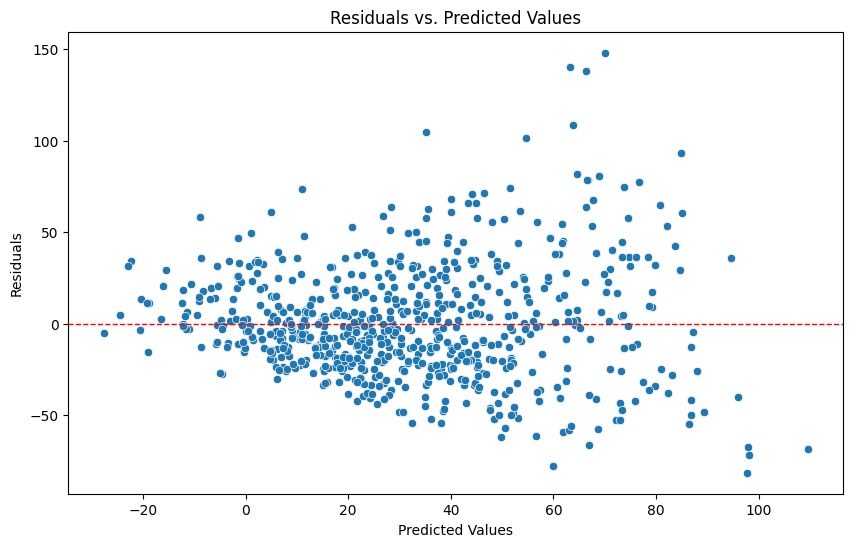

In [222]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Get residuals ---
residuals = y_train - ols_model.predict(sm.add_constant(X_train))

# --- Plot residuals vs. predicted values ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=ols_model.predict(sm.add_constant(X_train)), y=residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")
plt.show()


kinda a trend possibly

In [223]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# --- Fit Multilinear Regression Model ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# --- Predict on test data ---
y_pred = lin_reg.predict(X_test)

# --- Evaluate Model ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Multilinear Regression Results:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# --- Detailed Regression Stats with Statsmodels ---
X_train_sm = sm.add_constant(X_train)  # Add constant (intercept)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print("\n📄 OLS Summary:")
print(ols_model.summary())


📊 Multilinear Regression Results:
Mean Squared Error (MSE): 983.7741
R² Score: 0.1984

📄 OLS Summary:
                                  OLS Regression Results                                  
Dep. Variable:     GDP (current US$) 5Yr % Change   R-squared:                       0.392
Model:                                        OLS   Adj. R-squared:                  0.367
Method:                             Least Squares   F-statistic:                     15.80
Date:                            Sat, 03 May 2025   Prob (F-statistic):           6.04e-55
Time:                                    00:42:40   Log-Likelihood:                -3346.4
No. Observations:                             691   AIC:                             6749.
Df Residuals:                                 663   BIC:                             6876.
Df Model:                                      27                                         
Covariance Type:                        nonrobust                              

In [224]:
from sklearn.tree import DecisionTreeRegressor

# --- Fit Decision Tree Regressor ---
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# --- Predict on test data ---
y_pred_tree = tree_reg.predict(X_test)

# --- Evaluate model ---
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("🌳 Decision Tree Regression Results:")
print(f"Mean Squared Error (MSE): {mse_tree:.4f}")
print(f"R² Score: {r2_tree:.4f}")


🌳 Decision Tree Regression Results:
Mean Squared Error (MSE): 1302.6655
R² Score: -0.0614


In [225]:
#pip install tensorflow


In [226]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
# --- Prepare Data (Assuming X_train, y_train, X_test, y_test are already defined) ---

# Normalize the features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Create and Train the MLP Regressor ---
mlp_regressor = MLPRegressor(hidden_layer_sizes=(64, 32, 16),  # Define architecture with layers
                             activation='relu',               # Activation function for hidden layers
                             solver='adam',                   # Optimizer
                             max_iter=1000,                   # Maximum number of iterations
                             random_state=42)                 # Random state for reproducibility

# Fit the model
mlp_regressor.fit(X_train_scaled, y_train)

# --- Evaluate the Model ---
y_pred = mlp_regressor.predict(X_test_scaled)

# Evaluate performance using Mean Squared Error (MSE) and R² Score
mse_mlp = mean_squared_error(y_test, y_pred)
r2_mlp = r2_score(y_test, y_pred)

print("⚡ MLP Regressor Results:")
print(f"Mean Squared Error (MSE): {mse_mlp:.4f}")
print(f"R² Score: {r2_mlp:.4f}")


⚡ MLP Regressor Results:
Mean Squared Error (MSE): 444.4762
R² Score: 0.6378


bad resutls above

In [227]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- Fit Gradient Boosting Regressor ---
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

# --- Predict on test data ---
y_pred_gbr = gbr.predict(X_test)

# --- Evaluate model ---
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("🚀 Gradient Boosting Regression Results:")
print(f"Mean Squared Error (MSE): {mse_gbr:.4f}")
print(f"R² Score: {r2_gbr:.4f}")


🚀 Gradient Boosting Regression Results:
Mean Squared Error (MSE): 476.7406
R² Score: 0.6116


crazzy good MSE and R

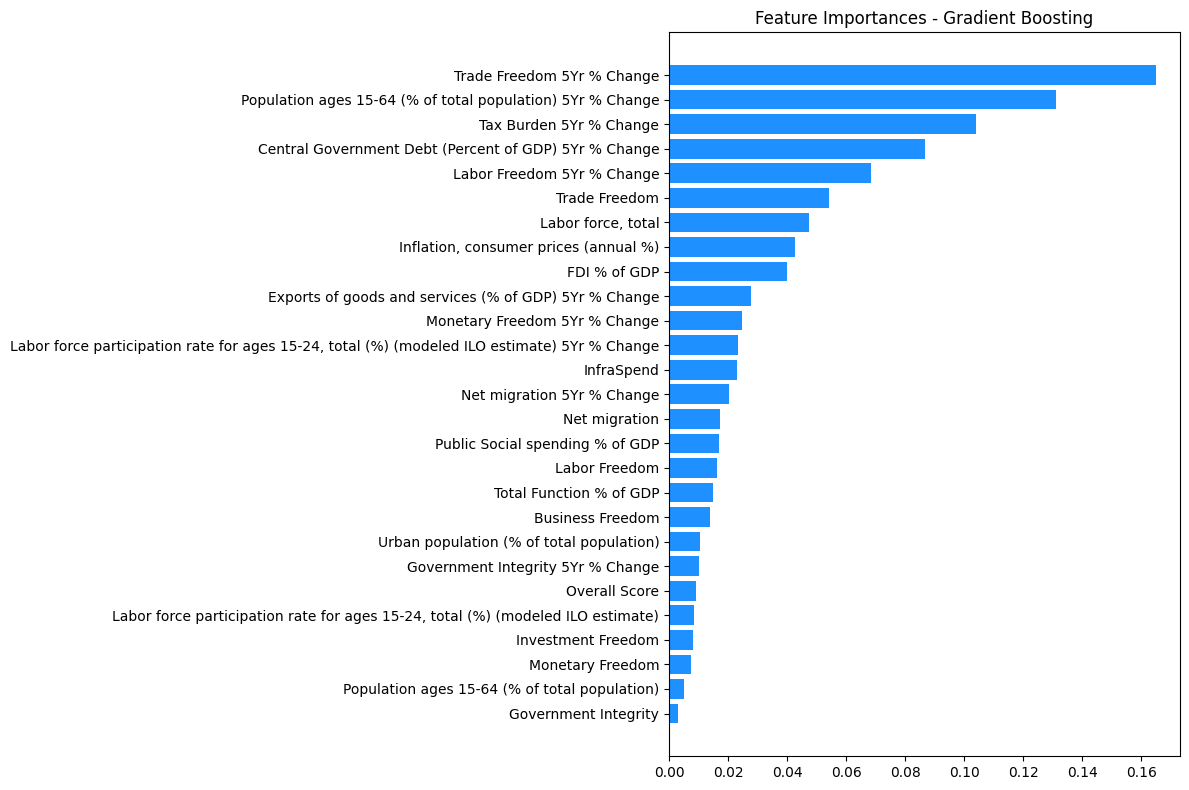

In [228]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting feature importances
importances = gbr.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(12, 8))
plt.title("Feature Importances - Gradient Boosting")
plt.barh(range(len(importances)), importances[indices], color="dodgerblue")
plt.yticks(range(len(importances)), features[indices])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



🔍 Running SHAP value analysis for Gradient Boosting Regressor...


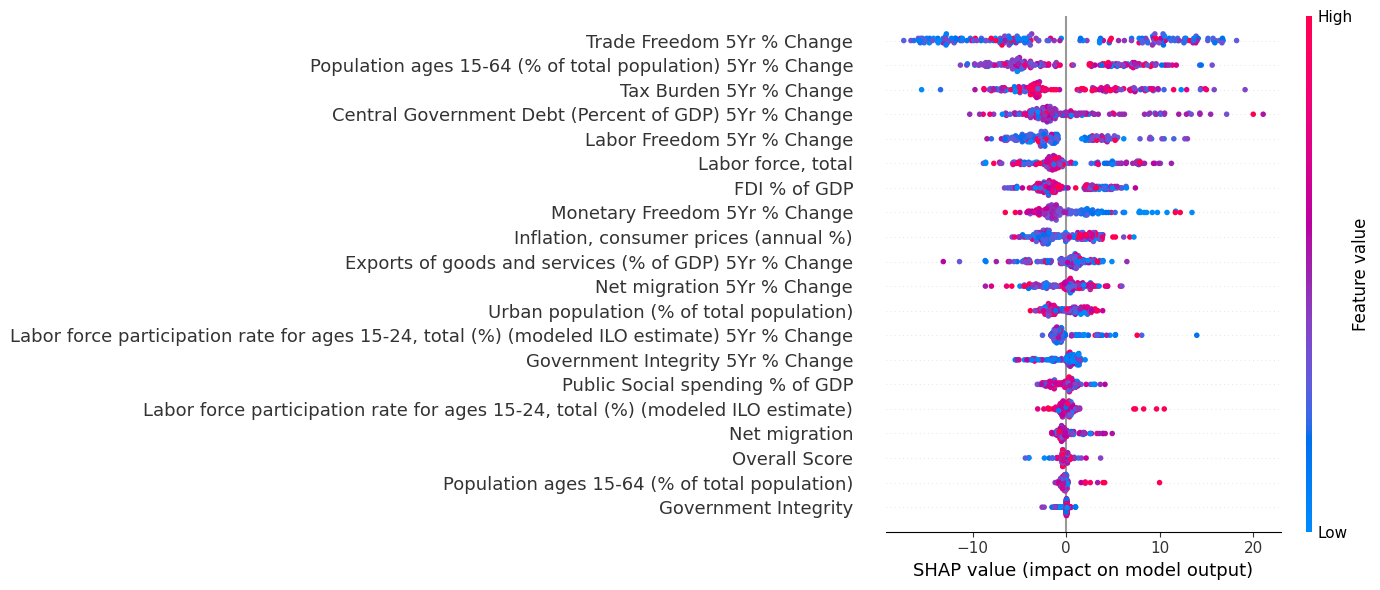

In [229]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Run SHAP Analysis ---
print("\n🔍 Running SHAP value analysis for Gradient Boosting Regressor...")

# Create SHAP TreeExplainer
explainer = shap.Explainer(gbr)  # You can also use shap.TreeExplainer(gbr)
shap_values = explainer(X_test)

# --- Get mean absolute SHAP values for each feature ---
shap_values_array = shap_values.values if hasattr(shap_values, 'values') else shap_values
mean_shap = np.abs(shap_values_array).mean(axis=0)

# --- Feature importance DataFrame ---
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': mean_shap
}).sort_values(by='importance', ascending=False)

# --- Select top 20 features ---
top_features = feature_importance['feature'].head(20).values

# --- Summary Plot for Top 20 Features ---
shap.summary_plot(shap_values[:, :20], X_test[top_features], plot_size=(14, 6))


The model is learning patterns over time, like "how did macro variables move historically in different years."

More recent years (say 2013 vs. 2000) are naturally more relevant for predicting 2018–2023.

Year becomes a way to contextualize what the world economy looked like at the time.

In [230]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# --- Fit XGBoost Regressor ---
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)
xgb_reg.fit(X_train, y_train)

# --- Predict on test data ---
y_pred_xgb = xgb_reg.predict(X_test)

# --- Evaluate model ---
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("⚡ XGBoost Regression Results:")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"R² Score: {r2_xgb:.4f}")


⚡ XGBoost Regression Results:
Mean Squared Error (MSE): 689.8136
R² Score: 0.4379


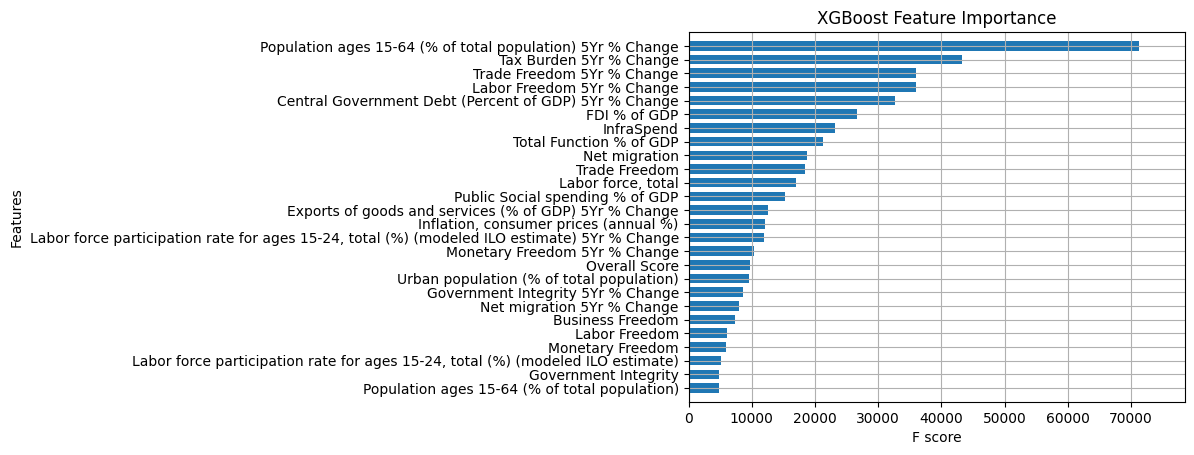

<Figure size 800x1800 with 0 Axes>

In [231]:
import matplotlib.pyplot as plt

# Set the figure size to make it taller
 # width=8, height=14

xgb.plot_importance(xgb_reg, height=0.7, importance_type='gain', show_values=False)
plt.title('XGBoost Feature Importance')
plt.figure(figsize=(8, 18)) 
plt.tight_layout()
plt.show()

## Baseline for classifier

In [232]:
# Find the value counts in the DataFrame
value_counts = df['FDI_Next1Yr_Above20'].value_counts()

# Get the most frequent count
most_frequent_count = value_counts.max()

# Calculate the percentage
percentage_most_frequent = (most_frequent_count / len(df['FDI_Next1Yr_Above20'])) * 100

print(f"The most frequent value makes up {percentage_most_frequent:.2f}% of the total.")




The most frequent value makes up 51.72% of the total.


# CLASSIFIER for FDI

In [233]:

# Define feature columns (X) and target column (y)
X_columns = [
    #'Year',# possibly want to take it out but i think we need it so it adds more importance to values closer to the year.
    #'GDP (current US$) 5Yr % Change', # made it worse by 2%, also no correlation in matrix
    #'Real interest rate (%) 5Yr % Change', 
    'Population ages 15-64 (% of total population) 1Yr % Change',
    #'Net migration 5Yr % Change',
    #'Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change', # keep bc has high model importance and kinda ok corr *
    #'Public Social spending % of GDP 5Yr % Change', # same as above *
    #'Urban population (% of total population) 5Yr % Change', # good corr and high model importance 
    #'Labor force, total 5Yr % Change', # low corr and no model importance 
    #'Imports of goods and services (% of GDP) 5Yr % Change', # some importance and little corr *
    #'Tax revenue (% of GDP) 5Yr % Change', # 0 corr but high model importance *
    #'Current account balance (BoP, current US$) 5Yr % Change', # smallll corr, medium relevance for model *
    #'Inflation, consumer prices (annual %) 5Yr % Change', # no corr but has significance in shap *
    #'Profit tax (% of commercial profits) 5Yr % Change', # i think absolute profit tax is more important, no corr, low importance, 
    #'Exports of goods and services (% of GDP) 5Yr % Change', # has ok corr but no significance, werid one *
    #'Population growth (annual %) 5Yr % Change', # weird how this has no impact... take it out tho, no corr **
    #'Mining, manufacturing and construction/Total function 5Yr % Change', # no corr , but medium impact in both
    #'Housing and community amenities/Total function 5Yr % Change', # no corr, no signi
    'Central Government Debt (Percent of GDP) 1Yr % Change', # no corr, above medium signifi
    #'FDI % of GDP 5Yr % Change', # little lower than medium signif, no corr, prob should tak it out *
    #'Overall Score 5Yr % Change', # good everything
    #'Property Rights 5Yr % Change', # bad all, kinda surprising 
    #'Government Integrity 5Yr % Change', # small corr, little relevence *
    'Tax Burden 1Yr % Change', # no corr, medium signif in both
    #'Government Spending 5Yr % Change', # bad all 
    #'Business Freedom 5Yr % Change', # good corr, good sig in the one 
    #'Labor Freedom 5Yr % Change', # badd 
    #'Monetary Freedom 5Yr % Change', # highest corrrrrrrrrrr , top 5 relevanve
    #'Trade Freedom 5Yr % Change', # great corr , sig in shap and below medium in the other
    #'Investment Freedom 5Yr % Change', # good all 
    #'Financial Freedom 5Yr % Change', # bad corr , medium in one and low in the other **
    #'Total Function % of GDP 5Yr % Change', # good all around top 5 corrrr
    #'Country Name', # high sig in both
    #"GDP (current US$)",# kinda
    #'Population ages 15-64 (% of total population)',
    #"Net migration",
    #"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",
    #"Public Social spending % of GDP",
    #"Urban population (% of total population)",
    "Labor force, total",
    #"Tax revenue (% of GDP)",# kinda
    #"Current account balance (BoP, current US$)", # check 
    #"Inflation, consumer prices (annual %)",# kinda
    #"Profit tax (% of commercial profits)",
    #"Population growth (annual %)",
    #"Mining, manufacturing and construction/Total function",
    #"Housing and community amenities/Total function", # kinda
    #"Central Government Debt (Percent of GDP)", # big
    #"FDI % of GDP", # interesting bc i shouldve include it
    #"Overall Score",
    "Property Rights",
    "Government Integrity",
    #"Tax Burden", # check
    #"Government Spending",# big, why i take it out of the other.. 
    #"Business Freedom", # big
    #"Labor Freedom", #small
    #"Monetary Freedom",
    #"Trade Freedom", #bbig
    #"Investment Freedom",
    #"Financial Freedom", #interesting
    #"Total Function % of GDP",
    #"Categorized/Total function"
]

#y_column = 'FDI % of GDP Next 5Yr % Change'
y_column = 'FDI_Next1Yr_Above20'

X = df[X_columns].copy() # if I want to leak the data to only understand relationships.
y = df[y_column].copy()


# Drop rows with NA in X
X = X.dropna()

# Then align y to match X's index
y = y.loc[X.index]


#### SCALING ## only required for linear regression and multi linear
#from sklearn.preprocessing import RobustScaler

# Initialize the RobustScaler
#scaler = RobustScaler()

# Fit and transform only X (not y)
#X_scaled = scaler.fit_transform(X)

# If you want it back as a DataFrame
#X_scaled = pd.DataFrame(X_scaled, columns=X_columns, index=X.index)



In [234]:
# when NEXT year is the target use the code below for splitting
#train_df = df[df['Year'] <= 2017] # when not using NEXT 
train_df = df[(df['Year'] > 2000) & (df['Year'] <= 2020)] # when using NEXT 

test_df = df[df['Year'] == 2022]

X_train = train_df[X_columns]
y_train = train_df[y_column]

X_test = test_df[X_columns]
y_test = test_df[y_column]

X_train.dropna(inplace=True)
y_train.dropna(inplace=True)

X_test.dropna(inplace=True)
y_test.dropna(inplace=True)

C:\Users\lukep\AppData\Local\Temp\ipykernel_14856\2032186633.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\lukep\AppData\Local\Temp\ipykernel_14856\2032186633.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\lukep\AppData\Local\Temp\ipykernel_14856\2032186633.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\lukep\AppData\Local\Temp\ipykernel_14856\2032186633.py:17: SettingWithCopyWarning:


A v

In [235]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- Dummy Classifier as a Benchmark ---
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)

# --- Predict on test data ---
y_pred_dummy = dummy_clf.predict(X_test)

# --- Evaluate dummy model ---
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
classification_rep_dummy = classification_report(y_test, y_pred_dummy)

print("📊 Dummy Classifier (Baseline) Results:")
print(f"Accuracy: {accuracy_dummy:.4f}")
print(f"Classification Report:\n{classification_rep_dummy}")

📊 Dummy Classifier (Baseline) Results:
Accuracy: 0.7500
Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        27
           1       0.00      0.00      0.00         9

    accuracy                           0.75        36
   macro avg       0.38      0.50      0.43        36
weighted avg       0.56      0.75      0.64        36



C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no pr

In [236]:
from sklearn.metrics import accuracy_score, classification_report

# --- Fit XGBoost Classifier ---
xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=4,  # Number of classes (bins)
    n_estimators=110,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)
xgb_clf.fit(X_train, y_train)

# --- Predict on test data ---
y_pred_xgb = xgb_clf.predict(X_test)

# --- Evaluate model ---
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
classification_rep = classification_report(y_test, y_pred_xgb)

print("⚡ XGBoost Classification Results:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Classification Report:\n{classification_rep}")

⚡ XGBoost Classification Results:
Accuracy: 0.8056
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86        27
           1       0.58      0.78      0.67         9

    accuracy                           0.81        36
   macro avg       0.75      0.80      0.76        36
weighted avg       0.83      0.81      0.81        36



In [237]:
import pandas as pd
import numpy as np

# Get predicted class probabilities (confidence scores)
y_proba = xgb_clf.predict_proba(X_test)

# Get the max confidence per prediction (i.e., probability of the predicted class)
max_confidences = np.max(y_proba, axis=1)

# Create comparison table
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_xgb,
    'Confidence (%)': (max_confidences * 100).round(2)
})

# Optionally: sort mismatches to inspect errors
comparison_df['Correct'] = comparison_df['Actual'] == comparison_df['Predicted']
comparison_df_sorted = comparison_df.sort_values(by='Correct')

# Display top rows
print(comparison_df_sorted.head(35))


      Actual  Predicted  Confidence (%)  Correct
27         0          1       55.450001    False
520        0          1       57.520000    False
85         0          1       56.680000    False
984        1          0       58.730000    False
201        1          0       75.790001    False
926        0          1       61.060001    False
259        0          1       74.160004    False
694        0          0       62.590000     True
723        0          0       84.150002     True
752        0          0       75.480003     True
781        0          0       61.180000     True
868        1          1       59.200001     True
839        1          1       52.259998     True
665        1          1       74.050003     True
897        0          0       60.020000     True
955        0          0       70.099998     True
1013       0          0       80.709999     True
810        0          0       83.370003     True
636        1          1       58.549999     True
549        0        

In [238]:
# Save feature order
features_used_in_training = X_train.columns.tolist()


In [239]:
# Prepare 2023 data
X_2023 = df[df['Year'] == 2023].copy()

# Only keep the features
X_2023 = X_2023[features_used_in_training]

# Drop missing rows
X_2023 = X_2023.dropna()

# Predict
y_pred_2023 = xgb_clf.predict(X_2023)

# Match predictions to country names
results_2023 = df[df['Year'] == 2023][['Country Code', 'Year']].copy()
results_2023 = results_2023.loc[X_2023.index]
results_2023['Prediction_for_2024'] = y_pred_2023

print(results_2023)


     Country Code  Year  Prediction_for_2024
28            AUS  2023                    0
57            AUT  2023                    0
86            BEL  2023                    1
115           CAN  2023                    0
144           CHL  2023                    1
202           COL  2023                    0
231           CRI  2023                    1
260           CZE  2023                    1
289           DNK  2023                    0
318           EST  2023                    1
347           FIN  2023                    0
376           FRA  2023                    0
405           DEU  2023                    0
434           GRC  2023                    1
463           HUN  2023                    0
492           ISL  2023                    0
521           IRL  2023                    1
550           ITA  2023                    0
579           JPN  2023                    0
608           KOR  2023                    0
637           LVA  2023                    1
666       

In [240]:
# Only show rows where prediction is 1
results_1_only = results_2023[results_2023['Prediction_for_2024'] == 1]

print(results_1_only)


    Country Code  Year  Prediction_for_2024
86           BEL  2023                    1
144          CHL  2023                    1
231          CRI  2023                    1
260          CZE  2023                    1
318          EST  2023                    1
434          GRC  2023                    1
521          IRL  2023                    1
637          LVA  2023                    1
666          LTU  2023                    1
840          POL  2023                    1
869          PRT  2023                    1
927          SVN  2023                    1


In [241]:
# Predict class probabilities (confidence)
y_proba_2023 = xgb_clf.predict_proba(X_2023)

# Get the confidence score (probability of the predicted class)
conf_2023 = y_proba_2023.max(axis=1)

# Add confidence to the results table
results_2023 = df[df['Year'] == 2023][['Country Code', 'Year']].copy()
results_2023 = results_2023.loc[X_2023.index]
results_2023['Prediction_for_2024'] = y_pred_2023
results_2023['Confidence (%)'] = (conf_2023 * 100).round(2)

# Sort by confidence if desired
results_2023 = results_2023.sort_values(by='Confidence (%)', ascending=False)

# Display results
print(results_2023.head(35))


     Country Code  Year  Prediction_for_2024  Confidence (%)
724           MEX  2023                    0       88.019997
260           CZE  2023                    1       84.080002
608           KOR  2023                    0       83.279999
202           COL  2023                    0       82.430000
347           FIN  2023                    0       80.639999
57            AUT  2023                    0       80.610001
1043          TUR  2023                    0       80.199997
550           ITA  2023                    0       80.050003
1014          CHE  2023                    0       79.589996
782           NZL  2023                    0       78.379997
956           ESP  2023                    0       76.139999
231           CRI  2023                    1       75.300003
753           NLD  2023                    0       74.269997
579           JPN  2023                    0       74.250000
811           NOR  2023                    0       73.180000
289           DNK  2023 

In [242]:
# Only show rows where prediction is 1
results_1_only = results_2023[results_2023['Prediction_for_2024'] == 1]
results_1_only

,Country Code,Year,Prediction_for_2024,Confidence (%)
260,CZE,2023,1,84.080002
231,CRI,2023,1,75.300003
144,CHL,2023,1,70.720001
318,EST,2023,1,66.129997
434,GRC,2023,1,63.490002
637,LVA,2023,1,58.709999
927,SVN,2023,1,58.439999
869,PRT,2023,1,55.250000
521,IRL,2023,1,53.450001
666,LTU,2023,1,53.360001


data here changed slightly

In [243]:
import plotly.express as px
import pandas as pd

# Sample data
data = {
    'Country Code': ['CZE', 'CRI', 'CHL', 'EST', 'GRC', 'LVA', 'SVN', 'PRT', 'IRL', 'LTU', 'BEL', 'POL'],
    'Confidence (%)': [84.92, 74.64, 70.73, 65.81, 62.70, 59.85, 58.13, 54.76, 53.62, 53.46, 52.15, 51.38]
}

# Mapping to full country names
code_to_name = {
    'CZE': 'Czech Republic',
    'CRI': 'Costa Rica',
    'CHL': 'Chile',
    'EST': 'Estonia',
    'GRC': 'Greece',
    'LVA': 'Latvia',
    'SVN': 'Slovenia',
    'PRT': 'Portugal',
    'IRL': 'Ireland',
    'LTU': 'Lithuania',
    'BEL': 'Belgium',
    'POL': 'Poland'
}

# Create DataFrame
df4 = pd.DataFrame(data)
df4['Country'] = df4['Country Code'].map(code_to_name)

# Plot
fig = px.bar(
    df4.sort_values(by='Confidence (%)', ascending=True),
    x='Confidence (%)',
    y='Country',
    orientation='h',
    color_discrete_sequence=['rgb(0,51,86)'],
    hover_data={'Confidence (%)': ':.2f'}
)

# Style and limit x-axis
fig.update_traces(marker_line_width=1.5, marker_line_color='rgb(255,206,0)')
fig.update_layout(
    title='Prediction Confidence for Positive FDI % GDP in 2024 by Country',
    xaxis_title='Confidence (%)',
    yaxis_title='',
    xaxis=dict(range=[50, 90]),
    plot_bgcolor='white',
    font=dict(family='Arial', size=12),
    height=500
)

fig.show()


Below is looking at the correlation of features to the residuals.

In [244]:
from scipy.stats import pearsonr

# --- Get residuals manually ---
residuals = y_test - y_pred_xgb

# --- Check correlation and p-value between residuals and each X variable ---
corrs = []
pvals = []

for col in X_test.columns:
    corr, pval = pearsonr(residuals, X_test[col])
    corrs.append(corr)
    pvals.append(pval)

# Combine into a DataFrame
resid_corr = pd.DataFrame({
    'Residual Correlation': corrs,
    'P-Value': pvals
}, index=X_test.columns)

# Sort by absolute correlation
resid_corr = resid_corr.reindex(resid_corr['Residual Correlation'].abs().sort_values(ascending=False).index)

print("Correlation and P-Value between residuals and X variables:")
print(resid_corr)



Correlation and P-Value between residuals and X variables:
                                                    Residual Correlation  \
Property Rights                                                -0.218054   
Labor force, total                                              0.174171   
Tax Burden 1Yr % Change                                         0.146479   
Population ages 15-64 (% of total population) 1...              0.093419   
Government Integrity                                           -0.065552   
Central Government Debt (Percent of GDP) 1Yr % ...              0.061190   

                                                     P-Value  
Property Rights                                     0.201395  
Labor force, total                                  0.309660  
Tax Burden 1Yr % Change                             0.393952  
Population ages 15-64 (% of total population) 1...  0.587873  
Government Integrity                                0.704063  
Central Government Debt (Perce

Graphing results that show feauture importance, how each feature predicts (direction it pushes) GDP growth, and which way the low and high values push GDP growth.

In [245]:
import shap

if you want to make a shap chart like in GDP regression for the classification you actually have to do regression for it

1. Feature Ranking (Top to Bottom)
The higher a feature is on the list (like "Population ages 15-64"), the more important it is in explaining model predictions.

"Year" is also way up there — that tells you your model is still very sensitive to time, as you guessed earlier.

2. Horizontal Spread (Left vs Right)
Left (Negative SHAP value) → That feature lowers the predicted GDP growth.

Right (Positive SHAP value) → That feature raises the predicted GDP growth.

Longer spread = bigger potential impact (good or bad).

3. Colors (Blue vs Red Dots)
Color = Actual feature value for that sample:

🔵 Blue = Lower feature value

🔴 Red = Higher feature value

So where the red/blue dots fall tells you how higher vs lower values of the feature impact the output.

Feature	Interpretation
Population ages 15-64 (% of total population)	- High population growth in working age → Slightly reduces GDP growth in some cases (leftward red dots)
- Low working-age growth → Mixed but generally less impact.
Public Social spending % of GDP	- High social spending changes (red) → Sometimes push GDP growth up, sometimes down → Depends (wide spread).
Monetary Freedom	- Higher "Monetary Freedom" (red) seems to increase GDP growth slightly (more right-side red dots).
Year	- Lower "Year" (older years, blue) reduce predicted growth → meaning, model sees time progression as boosting growth, or simply it uses "Year" as a strong trend feature.

In [246]:
#pip install shap

In [247]:
#pip install shap plotly


In [248]:
#pip install ipywidgets


# Index

First create the Debt Score var

In [249]:
# Create the new DebtScore column using the piecewise transformation
def calculate_debt_score(debt):
    if debt <= 90:
        return (90 - debt) / 90
    else:
        return -(debt - 90) / 110

# Apply the transformation to the DataFrame
df['DebtScore'] = df['Central Government Debt (Percent of GDP)'].apply(calculate_debt_score)

# Preview the result
df[['Central Government Debt (Percent of GDP)', 'DebtScore']].head()


,Central Government Debt (Percent of GDP),DebtScore
0,22.118423,0.754240
1,21.379758,0.762447
2,20.516577,0.772038
3,16.278476,0.819128
4,15.437900,0.828468


In [250]:
df

,Year,Country Name,Country Code,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),Central Government Debt (Percent of GDP),InfraSpend,"Mining, manufacturing and construction/Total function",Transport/Total function,Communication/Total function,Fuel and energy/Total function,Housing and community amenities/Total function,Health/Total function,Education/Total function,Public order and safety/Total function,RandD Economic affairs/Total function,FDI % of GDP,Overall Score,Property Rights,Government Integrity,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,Real interest rate (%) 1Yr % Change,Population ages 15-64 (% of total population) 1Yr % Change,GDP (current US$) 1Yr % Change,Net migration 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 1Yr % Change",Public Social spending % of GDP 1Yr % Change,Urban population (% of total population) 1Yr % Change,"Labor force, total 1Yr % Change",Imports of goods and services (% of GDP) 1Yr % Change,Tax revenue (% of GDP) 1Yr % Change,"Current account balance (BoP, current US$) 1Yr % Change","Inflation, consumer prices (annual %) 1Yr % Change",Profit tax (% of commercial profits) 1Yr % Change,Exports of goods and services (% of GDP) 1Yr % Change,Population growth (annual %) 1Yr % Change,Central Government Debt (Percent of GDP) 1Yr % Change,Categorized/Total function 1Yr % Change,"Mining, manufacturing and construction/Total function 1Yr % Change",Transport/Total function 1Yr % Change,Communication/Total function 1Yr % Change,Fuel and energy/Total function 1Yr % Change,Housing and community amenities/Total function 1Yr % Change,Health/Total function 1Yr % Change,Education/Total function 1Yr % Change,Public order and safety/Total function 1Yr % Change,RandD Economic affairs/Total function 1Yr % Change,FDI % of GDP 1Yr % Change,Overall Score 1Yr % Change,Property Rights 1Yr % Change,Government Integrity 1Yr % Change,Tax Burden 1Yr % Change,Government Spending 1Yr % Change,Business Freedom 1Yr % Change,Labor Freedom 1Yr % Change,Monetary Freedom 1Yr % Change,Trade Freedom 1Yr % Change,Investment Freedom 1Yr % Change,Financial Freedom 1Yr % Change,Total Function % of GDP 1Yr % Change,Real interest rate (%) Next 1Yr % Change,Population ages 15-64 (% of total population) Next 1Yr % Change,GDP (current US$) Next 1Yr % Change,Net migration Next 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 1Yr % Change",Public Social spending % of GDP Next 1Yr % Change,Urban population (% of total population) Next 1Yr % Change,"Labor force, total Next 1Yr % Change",Imports of goods and services (% of GDP) Next 1Yr % Change,Tax revenue (% of GDP) Next 1Yr % Change,"Current account balance (BoP, current US$) Next 1Yr % Change","Inflation, consumer prices (annual %) Next 1Yr % Change",Profit tax (% of commercial profits) Next 1Yr % Change,Exports of goods and services (% of GDP) Next 1Yr % Change,Population growth (annual %) Next 1Yr % Change,Central Government Debt (Percent of GDP) Next 1Yr % Change,Categorized/Total function Next 1Yr % Change,"Mining, manufacturing and construction/Total function Next 1Yr % Change",Transport/Total function Next 1Yr % Change,Communication/Total function Next 1Yr % Change,Fuel and energy/Total function Next 1Yr % Change,Housing and community amenities/Total function Next 1Yr % Change,Health/Total function Next 1Yr

In [259]:
from scipy.stats import zscore

# Filter to 2023 data only
df_2023 = df[df['Year'] == 2023].copy()

# Rename InfraSpend column if needed
# Ensure 'InfraSpend' exists or rename it from your defined name
# df_cleaned = df_cleaned.rename(columns={'Categorized/Total function, InfraSpend': 'InfraSpend'})

# Define the variables and weights for each dimension
# Dimension A: Inclusive Institutions
df_2023['Property Rights_z'] = zscore(df_2023['Property Rights'])
df_2023['Government Integrity_z'] = zscore(df_2023['Government Integrity'])

A_score = 0.5 * df_2023['Property Rights_z'] + 0.5 * df_2023['Government Integrity_z']

# Dimension B: Debt & Stability
# DebtScore is used directly (± direction), already bounded [-1, 1]
# The rest are z-scored and direction-adjusted

df_2023['Debt 5yr Δ_z'] = -zscore(df_2023['Central Government Debt (Percent of GDP) 5Yr % Change'])  # negative direction
df_2023['Inflation_z'] = -zscore(df_2023['Inflation, consumer prices (annual %)'])  # negative direction

# Real interest rate: positive up to 4%. We'll cap the values at 4% before z-scoring
real_rate_capped = df_2023['Real interest rate (%)'].clip(upper=4)
df_2023['Real Interest Rate_z'] = zscore(real_rate_capped)

B_score = (
    0.40 * df_2023['DebtScore'] +
    0.20 * df_2023['Debt 5yr Δ_z'] +
    0.20 * df_2023['Inflation_z'] +
    0.20 * df_2023['Real Interest Rate_z']
)

# Dimension C: Openness & Growth Capacity
df_2023['Trade Freedom_z'] = zscore(df_2023['Trade Freedom 5Yr % Change'])
df_2023['Pop1564_z'] = zscore(df_2023['Population ages 15-64 (% of total population) 5Yr % Change'])
df_2023['FDI_z'] = zscore(df_2023['FDI % of GDP'])
df_2023['Labor Freedom_z'] = zscore(df_2023['Labor Freedom 5Yr % Change'])
df_2023['Exports_z'] = zscore(df_2023['Exports of goods and services (% of GDP) 5Yr % Change'])
df_2023['InfraSpend_z'] = zscore(df_2023['InfraSpend'])

C_score = (
    0.25 * df_2023['Trade Freedom_z'] +
    0.15 * df_2023['Pop1564_z'] +
    0.15 * df_2023['FDI_z'] +
    0.15 * df_2023['Labor Freedom_z'] +
    0.15 * df_2023['Exports_z'] +
    0.15 * df_2023['InfraSpend_z']
)

# Final weighted index
df_2023['Investment_Potential_Index'] = (
    0.35 * A_score +
    0.35 * B_score +
    0.30 * C_score
)



In [260]:

# Display the resulting dataset with the index
df_2023[['Country Code', 'Investment_Potential_Index']].sort_values(by='Investment_Potential_Index', ascending=False).head(36)

,Country Code,Investment_Potential_Index
811,NOR,0.796785
28,AUS,0.690000
985,SWE,0.592334
695,LUX,0.497990
289,DNK,0.419170
492,ISL,0.372325
347,FIN,0.354247
1014,CHE,0.327753
57,AUT,0.314192
521,IRL,0.304510


# CLustering (not updated)

In [252]:
df_absolute5yr5yrNEXT = pd.read_csv("df_absolute5yr5yrNEXT.csv")
df_absolute5yr5yrNEXT.sample(5)

,Year,Country Name,Country Code,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),Central Government Debt (Percent of GDP),InfraSpend,"Mining, manufacturing and construction/Total function",Transport/Total function,Communication/Total function,Fuel and energy/Total function,Housing and community amenities/Total function,Health/Total function,Education/Total function,Public order and safety/Total function,RandD Economic affairs/Total function,FDI % of GDP,Overall Score,Property Rights,Government Integrity,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,Real interest rate (%) 1Yr % Change,Population ages 15-64 (% of total population) 1Yr % Change,GDP (current US$) 1Yr % Change,Net migration 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 1Yr % Change",Public Social spending % of GDP 1Yr % Change,Urban population (% of total population) 1Yr % Change,"Labor force, total 1Yr % Change",Imports of goods and services (% of GDP) 1Yr % Change,Tax revenue (% of GDP) 1Yr % Change,"Current account balance (BoP, current US$) 1Yr % Change","Inflation, consumer prices (annual %) 1Yr % Change",Profit tax (% of commercial profits) 1Yr % Change,Exports of goods and services (% of GDP) 1Yr % Change,Population growth (annual %) 1Yr % Change,Central Government Debt (Percent of GDP) 1Yr % Change,Categorized/Total function 1Yr % Change,"Mining, manufacturing and construction/Total function 1Yr % Change",Transport/Total function 1Yr % Change,Communication/Total function 1Yr % Change,Fuel and energy/Total function 1Yr % Change,Housing and community amenities/Total function 1Yr % Change,Health/Total function 1Yr % Change,Education/Total function 1Yr % Change,Public order and safety/Total function 1Yr % Change,RandD Economic affairs/Total function 1Yr % Change,FDI % of GDP 1Yr % Change,Overall Score 1Yr % Change,Property Rights 1Yr % Change,Government Integrity 1Yr % Change,Tax Burden 1Yr % Change,Government Spending 1Yr % Change,Business Freedom 1Yr % Change,Labor Freedom 1Yr % Change,Monetary Freedom 1Yr % Change,Trade Freedom 1Yr % Change,Investment Freedom 1Yr % Change,Financial Freedom 1Yr % Change,Total Function % of GDP 1Yr % Change,Real interest rate (%) Next 1Yr % Change,Population ages 15-64 (% of total population) Next 1Yr % Change,GDP (current US$) Next 1Yr % Change,Net migration Next 1Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 1Yr % Change",Public Social spending % of GDP Next 1Yr % Change,Urban population (% of total population) Next 1Yr % Change,"Labor force, total Next 1Yr % Change",Imports of goods and services (% of GDP) Next 1Yr % Change,Tax revenue (% of GDP) Next 1Yr % Change,"Current account balance (BoP, current US$) Next 1Yr % Change","Inflation, consumer prices (annual %) Next 1Yr % Change",Profit tax (% of commercial profits) Next 1Yr % Change,Exports of goods and services (% of GDP) Next 1Yr % Change,Population growth (annual %) Next 1Yr % Change,Central Government Debt (Percent of GDP) Next 1Yr % Change,Categorized/Total function Next 1Yr % Change,"Mining, manufacturing and construction/Total function Next 1Yr % Change",Transport/Total function Next 1Yr % Change,Communication/Total function Next 1Yr % Change,Fuel and energy/Total function Next 1Yr % Change,Housing and community amenities/Total function Next 1Yr % Change,Health/Total function Next 1Yr

In [253]:
df_absolute5yr5yrNEXTleaned2 = df_absolute5yr5yrNEXT.drop(columns=[ # bc they have too many missing data or are repeats
    'Judicial Effectiveness 5Yr % Change', 
    'Fiscal Health 5Yr % Change', 
    'Region 5Yr % Change', 
    'Judicial Effectiveness Next 5Yr % Change', 
    'Fiscal Health Next 5Yr % Change',
    'Total function Scaled (0-100, %GDP) Next 5Yr % Change',
    'Population Growth Scaled (0-100) Next 5Yr % Change', 
    'Population 15-64 Scaled (% of total, 0-100) Next 5Yr % Change',
    'Region Next 5Yr % Change',
    'Population Growth Scaled (0-100) 5Yr % Change',
    'Population 15-64 Scaled (% of total, 0-100) 5Yr % Change',
    'Region 5Yr % Change'


])



KeyError: "['Judicial Effectiveness 5Yr % Change', 'Fiscal Health 5Yr % Change', 'Region 5Yr % Change', 'Judicial Effectiveness Next 5Yr % Change', 'Fiscal Health Next 5Yr % Change', 'Total function Scaled (0-100, %GDP) Next 5Yr % Change', 'Population Growth Scaled (0-100) Next 5Yr % Change', 'Population 15-64 Scaled (% of total, 0-100) Next 5Yr % Change', 'Region Next 5Yr % Change', 'Population Growth Scaled (0-100) 5Yr % Change', 'Population 15-64 Scaled (% of total, 0-100) 5Yr % Change', 'Region 5Yr % Change'] not found in axis"

In [ ]:
# List of columns to fill NaN with mean
columns_to_fill = [
    "Real interest rate (%)", "Population ages 15-64 (% of total population)", "GDP (current US$)", 
    "Total function in mill", "Net migration", "Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",
    "Public Social spending % of GDP", "Foreign direct investment, net inflows (BoP, current US$)", 
    "Urban population (% of total population)", "Labor force, total", "Imports of goods and services (% of GDP)", 
    "Tax revenue (% of GDP)", "Current account balance (BoP, current US$)", "Inflation, consumer prices (annual %)", 
    "Profit tax (% of commercial profits)", "Exports of goods and services (% of GDP)", "Population growth (annual %)", 
    "Mining, manufacturing and construction/Total function", "Housing and community amenities/Total function", 
    "Central Government Debt (Percent of GDP)", "FDI % of GDP", "Index Year", "Overall Score", 
    "Property Rights", "Government Integrity", "Judicial Effectiveness", "Tax Burden", "Government Spending", 
    "Fiscal Health", "Business Freedom", "Labor Freedom", "Monetary Freedom", "Trade Freedom", "Investment Freedom", 
    "Financial Freedom", "Total Function % of GDP", 
    "Real interest rate (%) 5Yr % Change", "Population ages 15-64 (% of total population) 5Yr % Change", 
    "GDP (current US$) 5Yr % Change", "Total function in mill 5Yr % Change", "Net migration 5Yr % Change", 
    "Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change", 
    "Public Social spending % of GDP 5Yr % Change", "Foreign direct investment, net inflows (BoP, current US$) 5Yr % Change", 
    "Urban population (% of total population) 5Yr % Change", "Labor force, total 5Yr % Change", 
    "Imports of goods and services (% of GDP) 5Yr % Change", "Tax revenue (% of GDP) 5Yr % Change", 
    "Current account balance (BoP, current US$) 5Yr % Change", "Inflation, consumer prices (annual %) 5Yr % Change", 
    "Profit tax (% of commercial profits) 5Yr % Change", "Exports of goods and services (% of GDP) 5Yr % Change", 
    "Population growth (annual %) 5Yr % Change", "Mining, manufacturing and construction/Total function 5Yr % Change", 
    "Housing and community amenities/Total function 5Yr % Change", "Central Government Debt (Percent of GDP) 5Yr % Change", 
    "FDI % of GDP 5Yr % Change", "Index Year 5Yr % Change", "Overall Score 5Yr % Change", 
    "Property Rights 5Yr % Change", "Government Integrity 5Yr % Change", "Tax Burden 5Yr % Change", 
    "Government Spending 5Yr % Change", "Business Freedom 5Yr % Change", "Labor Freedom 5Yr % Change", 
    "Monetary Freedom 5Yr % Change", "Trade Freedom 5Yr % Change", "Investment Freedom 5Yr % Change", 
    "Financial Freedom 5Yr % Change", "Total Function % of GDP 5Yr % Change", "Real interest rate (%) Next 5Yr % Change",
    "Population ages 15-64 (% of total population) Next 5Yr % Change",
    "GDP (current US$) Next 5Yr % Change",
    "Total function in mill Next 5Yr % Change",
    "Net migration Next 5Yr % Change",
    "Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 5Yr % Change",
    "Public Social spending % of GDP Next 5Yr % Change",
    "Foreign direct investment, net inflows (BoP, current US$) Next 5Yr % Change",
    "Urban population (% of total population) Next 5Yr % Change",
    "Labor force, total Next 5Yr % Change",
    "Imports of goods and services (% of GDP) Next 5Yr % Change",
    "Tax revenue (% of GDP) Next 5Yr % Change",
    "Current account balance (BoP, current US$) Next 5Yr % Change",
    "Inflation, consumer prices (annual %) Next 5Yr % Change",
    "Profit tax (% of commercial profits) Next 5Yr % Change",
    "Exports of goods and services (% of GDP) Next 5Yr % Change",
    "Population growth (annual %) Next 5Yr % Change",
    "Mining, manufacturing and construction/Total function Next 5Yr % Change",
    "Housing and community amenities/Total function Next 5Yr % Change",
    "Central Government Debt (Percent of GDP) Next 5Yr % Change",
    "FDI % of GDP Next 5Yr % Change",
    "Index Year Next 5Yr % Change",
    "Overall Score Next 5Yr % Change",
    "Property Rights Next 5Yr % Change",
    "Government Integrity Next 5Yr % Change",
    "Judicial Effectiveness Next 5Yr % Change",
    "Tax Burden Next 5Yr % Change",
    "Government Spending Next 5Yr % Change",
    "Fiscal Health Next 5Yr % Change",
    "Business Freedom Next 5Yr % Change",
    "Labor Freedom Next 5Yr % Change",
    "Monetary Freedom Next 5Yr % Change",
    "Trade Freedom Next 5Yr % Change",
    "Investment Freedom Next 5Yr % Change",
    "Financial Freedom Next 5Yr % Change",
    "Total Function % of GDP Next 5Yr % Change"
]

# Loop through each column and fill NaNs with the mean
for col in columns_to_fill:
    if col in df_absolute5yr5yrNEXT.columns:
        df_absolute5yr5yrNEXT[col] = df_absolute5yr5yrNEXT[col].fillna(df_absolute5yr5yrNEXT[col].mean())


In [ ]:
df = df_absolute5yr5yrNEXT

In [ ]:
# List of columns to drop
columns_to_drop = [
    'Real interest rate (%) Next 5Yr % Change', 'Population ages 15-64 (% of total population) Next 5Yr % Change',
    'GDP (current US$) Next 5Yr % Change', 'Total function in mill Next 5Yr % Change', 'Net migration Next 5Yr % Change',
    'Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) Next 5Yr % Change', 
    'Public Social spending % of GDP Next 5Yr % Change', 'Urban population (% of total population) Next 5Yr % Change', 
    'Labor force, total Next 5Yr % Change', 'Imports of goods and services (% of GDP) Next 5Yr % Change', 
    'Tax revenue (% of GDP) Next 5Yr % Change', 'Current account balance (BoP, current US$) Next 5Yr % Change', 
    'Inflation, consumer prices (annual %) Next 5Yr % Change', 'Profit tax (% of commercial profits) Next 5Yr % Change', 
    'Exports of goods and services (% of GDP) Next 5Yr % Change', 'Population growth (annual %) Next 5Yr % Change', 
    'Mining, manufacturing and construction/Total function Next 5Yr % Change', 'Housing and community amenities/Total function Next 5Yr % Change', 
    'Central Government Debt (Percent of GDP) Next 5Yr % Change', 'FDI % of GDP Next 5Yr % Change', 'Index Year Next 5Yr % Change', 
    'Overall Score Next 5Yr % Change', 'Property Rights Next 5Yr % Change', 'Government Integrity Next 5Yr % Change', 
    'Tax Burden Next 5Yr % Change', 'Government Spending Next 5Yr % Change', 'Business Freedom Next 5Yr % Change', 
    'Labor Freedom Next 5Yr % Change', 'Monetary Freedom Next 5Yr % Change', 'Trade Freedom Next 5Yr % Change', 
    'Investment Freedom Next 5Yr % Change', 'Financial Freedom Next 5Yr % Change', 'Total Function % of GDP Next 5Yr % Change', 
    'Total function Scaled (0-100, %GDP) Next 5Yr % Change', 'Population Growth Scaled (0-100) Next 5Yr % Change', 
    'Population 15-64 Scaled (% of total, 0-100) Next 5Yr % Change', 'Region Next 5Yr % Change', 'Region 5Yr % Change', 'Index Year', 'Region', 'Region 5Yr % Change', 'Region Next 5Yr % Change'
]

# Drop the columns from the dataframe
df_cleaned1 = df.drop(columns=columns_to_drop)

# Show the resulting dataframe
df_cleaned1.head()


,Year,Country Name,Country Code,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Total function in mill,Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,"Foreign direct investment, net inflows (BoP, current US$)",Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),"Mining, manufacturing and construction/Total function",Housing and community amenities/Total function,Central Government Debt (Percent of GDP),FDI % of GDP,Overall Score,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,"Total function Scaled (0-100, %GDP)",Population Growth Scaled (0-100),"Population 15-64 Scaled (% of total, 0-100)",Real interest rate (%) 5Yr % Change,Population ages 15-64 (% of total population) 5Yr % Change,GDP (current US$) 5Yr % Change,Total function in mill 5Yr % Change,Net migration 5Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change",Public Social spending % of GDP 5Yr % Change,"Foreign direct investment, net inflows (BoP, current US$) 5Yr % Change",Urban population (% of total population) 5Yr % Change,"Labor force, total 5Yr % Change",Imports of goods and services (% of GDP) 5Yr % Change,Tax revenue (% of GDP) 5Yr % Change,"Current account balance (BoP, current US$) 5Yr % Change","Inflation, consumer prices (annual %) 5Yr % Change",Profit tax (% of commercial profits) 5Yr % Change,Exports of goods and services (% of GDP) 5Yr % Change,Population growth (annual %) 5Yr % Change,"Mining, manufacturing and construction/Total function 5Yr % Change",Housing and community amenities/Total function 5Yr % Change,Central Government Debt (Percent of GDP) 5Yr % Change,FDI % of GDP 5Yr % Change,Index Year 5Yr % Change,Overall Score 5Yr % Change,Property Rights 5Yr % Change,Government Integrity 5Yr % Change,Judicial Effectiveness 5Yr % Change,Tax Burden 5Yr % Change,Government Spending 5Yr % Change,Fiscal Health 5Yr % Change,Business Freedom 5Yr % Change,Labor Freedom 5Yr % Change,Monetary Freedom 5Yr % Change,Trade Freedom 5Yr % Change,Investment Freedom 5Yr % Change,Financial Freedom 5Yr % Change,Total Function % of GDP 5Yr % Change,"Total function Scaled (0-100, %GDP) 5Yr % Change",Population Growth Scaled (0-100) 5Yr % Change,"Population 15-64 Scaled (% of total, 0-100) 5Yr % Change","Foreign direct investment, net inflows (BoP, current US$) Next 5Yr % Change",Judicial Effectiveness Next 5Yr % Change,Fiscal Health Next 5Yr % Change
0,1995,Australia,AUS,8.027105,66.618171,3.681660e+11,567527.037787,80456.0,71.645,16.880,1.326888e+10,84.898,8978015.0,19.833376,21.159594,-1.866924e+10,4.627767,15.488268,17.870670,1.113734,0.002619,0.016918,22.118423,3.604047,74.100000,90.000000,70.00000,69.568797,59.600000,53.90000,75.894737,70.000000,63.854986,86.700000,77.000000,70.00000,90.000000,0.000043,47.144779,66.216940,54.193683,-31.13299,-0.31229,31.705772,32.766428,-76.026152,-2.672859,inf,398.626983,1.81903,4.637368,7.897537,0.992702,565.942408,-124470.651428,0.601597,8.92641,214.841294,inf,8.34828,23.304729,196.790608,0.249193,1.913004,2.940126,5.110757,NaN,4.341201,inf,NaN,1.567716,0.192958,inf,3.071046,3.728156,3.395175,3.350555,46.896114,3.45483,-1.028462,12.239945,14.688337,-5.50768
1,1995,Austria,AUT,4.000943,67.040855,2.400940e+11,567527.037787,1890.0,61.758,26.556,1.083553e+09,61.596,3882448.0,34.860005,24.696840,-7.790624e+08,2.243366,15.488268,33.665001,0.153106,0.002619,0.016918,55.248115,0.451304,70.000000,90.000000,90.00000,69.568797,46.30000

In [ ]:
df_latest = df_cleaned1[df_cleaned1["Year"] > 2000]


In [ ]:
df_latest

,Year,Country Name,Country Code,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Total function in mill,Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,"Foreign direct investment, net inflows (BoP, current US$)",Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),"Mining, manufacturing and construction/Total function",Housing and community amenities/Total function,Central Government Debt (Percent of GDP),FDI % of GDP,Overall Score,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,"Total function Scaled (0-100, %GDP)",Population Growth Scaled (0-100),"Population 15-64 Scaled (% of total, 0-100)",Real interest rate (%) 5Yr % Change,Population ages 15-64 (% of total population) 5Yr % Change,GDP (current US$) 5Yr % Change,Total function in mill 5Yr % Change,Net migration 5Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change",Public Social spending % of GDP 5Yr % Change,"Foreign direct investment, net inflows (BoP, current US$) 5Yr % Change",Urban population (% of total population) 5Yr % Change,"Labor force, total 5Yr % Change",Imports of goods and services (% of GDP) 5Yr % Change,Tax revenue (% of GDP) 5Yr % Change,"Current account balance (BoP, current US$) 5Yr % Change","Inflation, consumer prices (annual %) 5Yr % Change",Profit tax (% of commercial profits) 5Yr % Change,Exports of goods and services (% of GDP) 5Yr % Change,Population growth (annual %) 5Yr % Change,"Mining, manufacturing and construction/Total function 5Yr % Change",Housing and community amenities/Total function 5Yr % Change,Central Government Debt (Percent of GDP) 5Yr % Change,FDI % of GDP 5Yr % Change,Index Year 5Yr % Change,Overall Score 5Yr % Change,Property Rights 5Yr % Change,Government Integrity 5Yr % Change,Judicial Effectiveness 5Yr % Change,Tax Burden 5Yr % Change,Government Spending 5Yr % Change,Fiscal Health 5Yr % Change,Business Freedom 5Yr % Change,Labor Freedom 5Yr % Change,Monetary Freedom 5Yr % Change,Trade Freedom 5Yr % Change,Investment Freedom 5Yr % Change,Financial Freedom 5Yr % Change,Total Function % of GDP 5Yr % Change,"Total function Scaled (0-100, %GDP) 5Yr % Change",Population Growth Scaled (0-100) 5Yr % Change,"Population 15-64 Scaled (% of total, 0-100) 5Yr % Change","Foreign direct investment, net inflows (BoP, current US$) Next 5Yr % Change",Judicial Effectiveness Next 5Yr % Change,Fiscal Health Next 5Yr % Change
228,2001,Australia,AUS,2.113075,66.985140,3.796290e+11,145149.000000,117552.0,70.673,17.509000,1.071713e+10,84.100,9692586.0,22.066378,24.857860,-7.986938e+09,4.407135,15.488268,22.152326,1.283968,0.010389,0.017520,11.980421,2.823054,77.4,90.0,87.0,69.568797,55.4,67.3,75.894737,70.0,63.854986,87.9,79.0,70.0,90.0,0.000038,35.527063,69.379379,56.716371,-69.073025,0.510535,-5.410099,32.766428,41.688664,-1.384218,3.006236,134.821315,-0.786863,6.495936,14.079927,13.649652,-44.553410,68.508117,0.601597,17.269237,5.776070,inf,8.348280,-43.963724,148.251994,0.250501,4.594595,0.000000,24.285714,NaN,-6.576728,26.029963,NaN,0.000000,0.192958,1.618497,2.597403,0.000000,0.000000,3.350555,46.896114,1.913268,4.301372,185.067846,14.688337,-5.50768
229,2001,Austria,AUT,4.000943,67.719529,1.964770e+11,101432.000000,39866.0,54.684,26.092000,3.021897e+09,59.934,3896148.0,43.144447,28.112400,-7.790624e+08,2.650001,15.488268,44.851810,0.382799,0.000542,0.011002,55.056343,1.538041,68.1,90.0,76.0,69.568797,44.2,25.0,75.894737,70.0,63.854986,89

In [ ]:
# this is to use above in the regression models. 
#from sklearn.model_selection import train_test_split

# Define the target variable
#y_column = ''GDP (current US$)''

# Define the input features
#X_columns = [
    'Year',
    'Real interest rate (%)',
    'Population ages 15-64 (% of total population)',
    'Total function in mill',
    'Net migration',
    'Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)',
    'Public Social spending % of GDP',
    'Urban population (% of total population)',
    'Labor force, total',
    'Imports of goods and services (% of GDP)',
    'Tax revenue (% of GDP)',
    'Current account balance (BoP, current US$)',
    'Inflation, consumer prices (annual %)',
    'Profit tax (% of commercial profits)',
    'Exports of goods and services (% of GDP)',
    'Population growth (annual %)',
    'Mining, manufacturing and construction/Total function',
    'Housing and community amenities/Total function',
    'Central Government Debt (Percent of GDP)',
    'Overall Score',
    'Property Rights',
    'Government Integrity',
    'Judicial Effectiveness',
    'Tax Burden',
    'Government Spending',
    'Fiscal Health',
    'Business Freedom',
    'Labor Freedom',
    'Monetary Freedom',
    'Trade Freedom',
    'Investment Freedom',
    'Financial Freedom'
]

# Filter down to only the columns you need
#df_model = df_latest_cleaned[X_columns + [y_column]].dropna()

# Define X and y
#X = df_model[X_columns]
#y = df_model[y_column]

# Split into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42
#)


In [ ]:
# Drop 'Country Name' and 'Country Code' columns from df_latest
df_latest_cleaned = df_latest.drop(columns=['Country Name', 'Country Code', 'Government Spending 5Yr % Change', 'Mining, manufacturing and construction/Total function 5Yr % Change'])

# Show the resulting dataframe
df_latest_cleaned.head()


,Year,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Total function in mill,Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,"Foreign direct investment, net inflows (BoP, current US$)",Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),"Mining, manufacturing and construction/Total function",Housing and community amenities/Total function,Central Government Debt (Percent of GDP),FDI % of GDP,Overall Score,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,"Total function Scaled (0-100, %GDP)",Population Growth Scaled (0-100),"Population 15-64 Scaled (% of total, 0-100)",Real interest rate (%) 5Yr % Change,Population ages 15-64 (% of total population) 5Yr % Change,GDP (current US$) 5Yr % Change,Total function in mill 5Yr % Change,Net migration 5Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change",Public Social spending % of GDP 5Yr % Change,"Foreign direct investment, net inflows (BoP, current US$) 5Yr % Change",Urban population (% of total population) 5Yr % Change,"Labor force, total 5Yr % Change",Imports of goods and services (% of GDP) 5Yr % Change,Tax revenue (% of GDP) 5Yr % Change,"Current account balance (BoP, current US$) 5Yr % Change","Inflation, consumer prices (annual %) 5Yr % Change",Profit tax (% of commercial profits) 5Yr % Change,Exports of goods and services (% of GDP) 5Yr % Change,Population growth (annual %) 5Yr % Change,Housing and community amenities/Total function 5Yr % Change,Central Government Debt (Percent of GDP) 5Yr % Change,FDI % of GDP 5Yr % Change,Index Year 5Yr % Change,Overall Score 5Yr % Change,Property Rights 5Yr % Change,Government Integrity 5Yr % Change,Judicial Effectiveness 5Yr % Change,Tax Burden 5Yr % Change,Fiscal Health 5Yr % Change,Business Freedom 5Yr % Change,Labor Freedom 5Yr % Change,Monetary Freedom 5Yr % Change,Trade Freedom 5Yr % Change,Investment Freedom 5Yr % Change,Financial Freedom 5Yr % Change,Total Function % of GDP 5Yr % Change,"Total function Scaled (0-100, %GDP) 5Yr % Change",Population Growth Scaled (0-100) 5Yr % Change,"Population 15-64 Scaled (% of total, 0-100) 5Yr % Change","Foreign direct investment, net inflows (BoP, current US$) Next 5Yr % Change",Judicial Effectiveness Next 5Yr % Change,Fiscal Health Next 5Yr % Change
228,2001,2.113075,66.985140,3.796290e+11,145149.000000,117552.0,70.673,17.509,1.071713e+10,84.100,9692586.0,22.066378,24.857860,-7.986938e+09,4.407135,15.488268,22.152326,1.283968,0.010389,0.017520,11.980421,2.823054,77.4,90.0,87.0,69.568797,55.4,67.3,75.894737,70.0,63.854986,87.9,79.0,70.0,90.0,0.000038,35.527063,69.379379,56.716371,-69.073025,0.510535,-5.410099,32.766428,41.688664,-1.384218,3.006236,134.821315,-0.786863,6.495936,14.079927,13.649652,-44.553410,68.508117,0.601597,17.269237,5.776070,8.34828,-43.963724,148.251994,0.250501,4.594595,0.0,24.285714,NaN,-6.576728,NaN,0.0,0.192958,1.618497,2.597403,0.0,0.000000,3.350555,46.896114,1.913268,4.301372,185.067846,14.688337,-5.50768
229,2001,4.000943,67.719529,1.964770e+11,101432.000000,39866.0,54.684,26.092,3.021897e+09,59.934,3896148.0,43.144447,28.112400,-7.790624e+08,2.650001,15.488268,44.851810,0.382799,0.000542,0.011002,55.056343,1.538041,68.1,90.0,76.0,69.568797,44.2,25.0,75.894737,70.0,63.854986,89.6,78.0,70.0,70.0,0.000052,67.936419,52.638345,61.764837,-31.132990,1.033790,-16.730451,32.766428,877.826833,-8.300634,-2.196566,59.966612,-2.260274,1.132900,19.740643,7.781475,565.942408,42

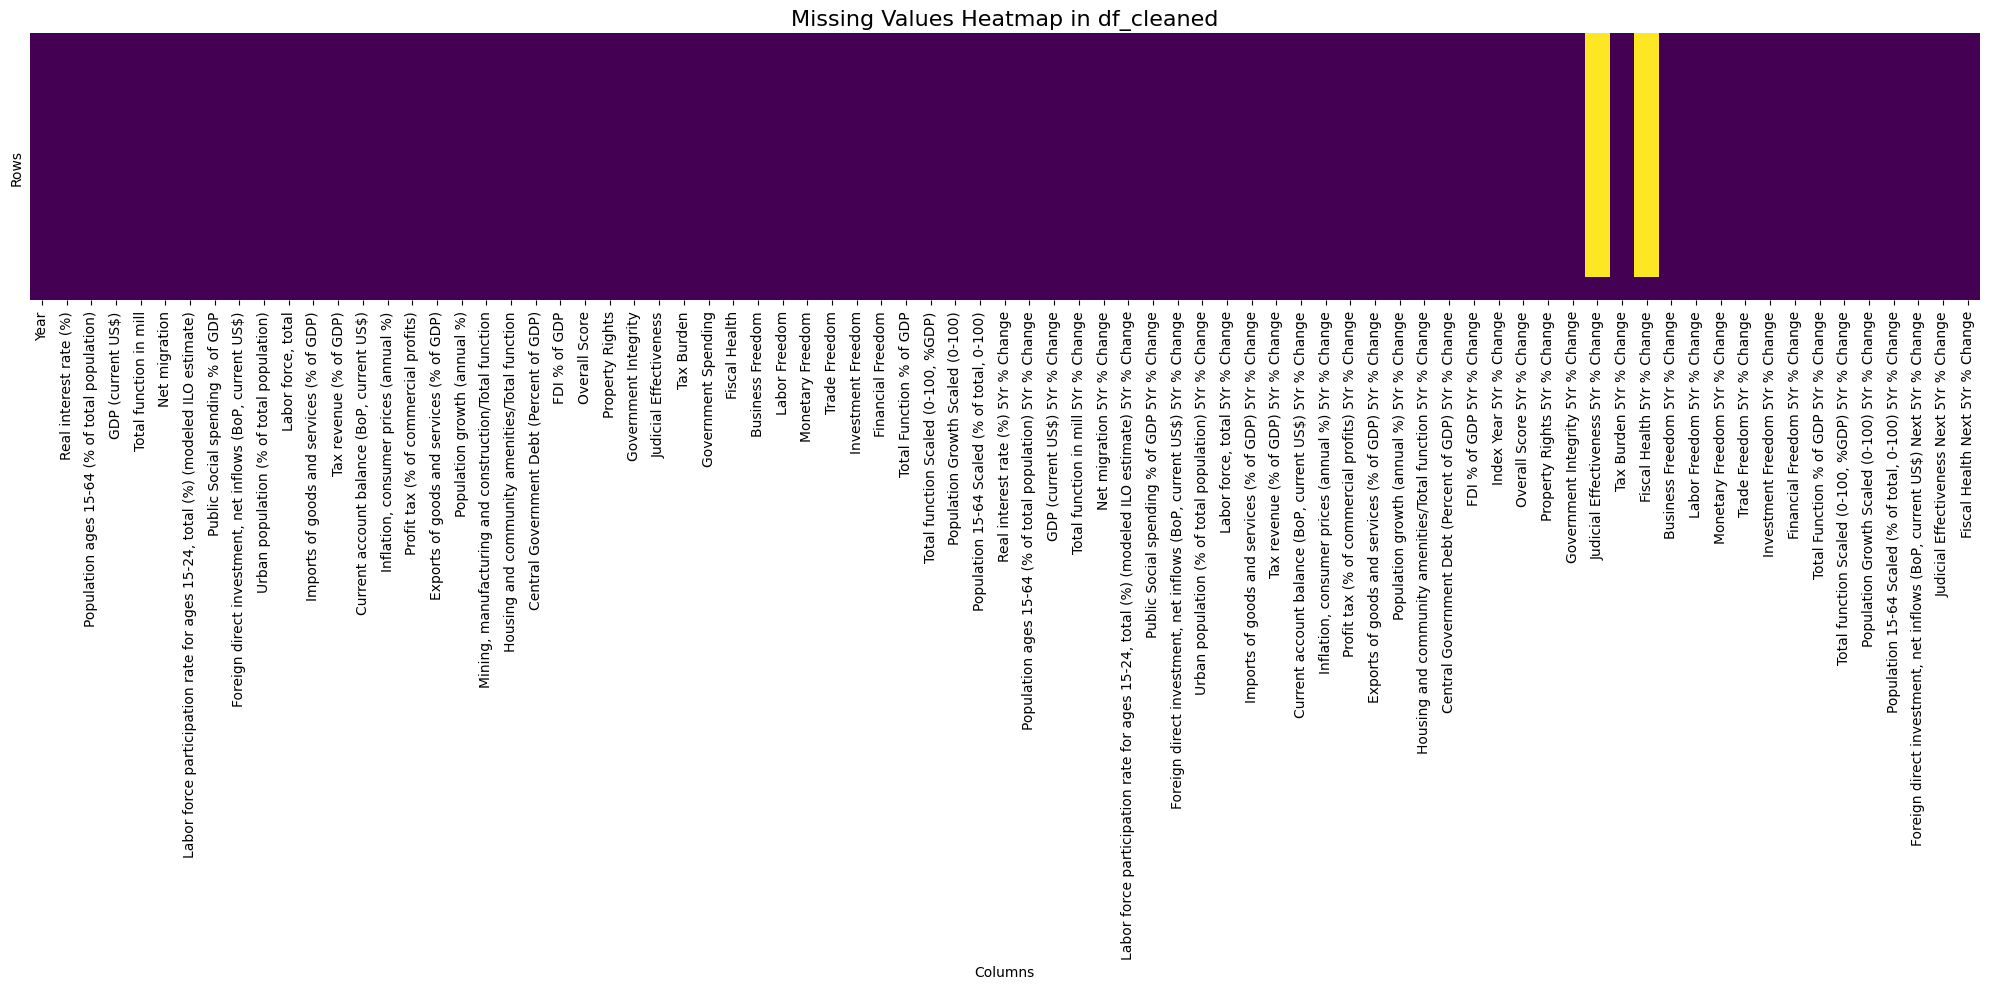

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(20, 10))

# Heatmap of missing values
sns.heatmap(df_latest_cleaned.isna(), 
            cbar=False, 
            cmap='viridis', 
            yticklabels=False)

plt.title('Missing Values Heatmap in df_cleaned', fontsize=16)
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()


In [ ]:
df_latest_cleaned.describe()

,Year,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Total function in mill,Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,"Foreign direct investment, net inflows (BoP, current US$)",Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),"Mining, manufacturing and construction/Total function",Housing and community amenities/Total function,Central Government Debt (Percent of GDP),FDI % of GDP,Overall Score,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,"Total function Scaled (0-100, %GDP)",Population Growth Scaled (0-100),"Population 15-64 Scaled (% of total, 0-100)",Real interest rate (%) 5Yr % Change,Population ages 15-64 (% of total population) 5Yr % Change,GDP (current US$) 5Yr % Change,Total function in mill 5Yr % Change,Net migration 5Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change",Public Social spending % of GDP 5Yr % Change,Urban population (% of total population) 5Yr % Change,"Labor force, total 5Yr % Change",Imports of goods and services (% of GDP) 5Yr % Change,Tax revenue (% of GDP) 5Yr % Change,"Current account balance (BoP, current US$) 5Yr % Change","Inflation, consumer prices (annual %) 5Yr % Change",Profit tax (% of commercial profits) 5Yr % Change,Exports of goods and services (% of GDP) 5Yr % Change,Population growth (annual %) 5Yr % Change,Housing and community amenities/Total function 5Yr % Change,Central Government Debt (Percent of GDP) 5Yr % Change,FDI % of GDP 5Yr % Change,Index Year 5Yr % Change,Overall Score 5Yr % Change,Property Rights 5Yr % Change,Government Integrity 5Yr % Change,Tax Burden 5Yr % Change,Business Freedom 5Yr % Change,Labor Freedom 5Yr % Change,Monetary Freedom 5Yr % Change,Trade Freedom 5Yr % Change,Investment Freedom 5Yr % Change,Financial Freedom 5Yr % Change,Total Function % of GDP 5Yr % Change,"Total function Scaled (0-100, %GDP) 5Yr % Change",Population Growth Scaled (0-100) 5Yr % Change,"Population 15-64 Scaled (% of total, 0-100) 5Yr % Change"
count,190.00000,190.000000,190.000000,1.900000e+02,1.900000e+02,1.900000e+02,190.000000,190.000000,1.900000e+02,190.000000,1.900000e+02,190.000000,190.000000,1.900000e+02,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,2021.00000,2.848576,65.317766,1.957436e+12,4.963306e+05,9.728783e+04,45.152195,21.422226,2.537065e+10,78.021358,3.830843e+07,51.598282,19.965192,4.127630e+09,5.005461,15.448947,54.685116,0.559362,0.001847,0.014846,64.762333,3.232417,71.832105,80.332632,73.171579,70.066842,66.612632,46.718421,75.282632,78.094211,63.110000,80.206316,82.349474,77.500000,68.526316,0.000044,49.640895,55.918357,45.254213,-41.759905,-1.384949,18.170742,24.342945,-249.962466,-1.340767,9.420987,1.599017,4.177342,6.524621,1.759139,-29.021597,128.471055,-2.160241,5.755303,978.217427,-0.458174,13.128866,-64.420933,0.248016,1.275491,12.037173,12.8

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your actual DataFrame name if different
column_name = "Mining, manufacturing and construction/Total function 5Yr % Change"

# Check if column exists and has data
if column_name in df_latest_cleaned.columns and df_latest_cleaned[column_name].notna().sum() > 0:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_latest_cleaned[column_name].dropna(), kde=True, bins=30, color='skyblue')
    plt.title("Distribution of Profit Tax (% of Commercial Profits)", fontsize=16)
    plt.xlabel("Profit Tax (%)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{column_name}' not found or contains no valid data.")


Column 'Mining, manufacturing and construction/Total function 5Yr % Change' not found or contains no valid data.


In [ ]:
import numpy as np

# Count original number of rows
original_row_count = df_latest_cleaned.shape[0]

# Replace inf and -inf with NaN (so we can drop them)
df_latest_cleaned =  df_latest_cleaned.replace([np.inf, -np.inf], np.nan)

# Drop rows with any NaN values (which now includes former inf values)
df_latest_cleaned = df_latest_cleaned.dropna()

# Count new number of rows
new_row_count = df_latest_cleaned.shape[0]

# Count of rows dropped
rows_dropped = original_row_count - new_row_count
print(f"Rows dropped due to inf or overflow values: {rows_dropped}")

Rows dropped due to inf or overflow values: 0


In [ ]:
df_latest_cleaned

,Year,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Total function in mill,Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,"Foreign direct investment, net inflows (BoP, current US$)",Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),"Mining, manufacturing and construction/Total function",Housing and community amenities/Total function,Central Government Debt (Percent of GDP),FDI % of GDP,Overall Score,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,"Total function Scaled (0-100, %GDP)",Population Growth Scaled (0-100),"Population 15-64 Scaled (% of total, 0-100)",Real interest rate (%) 5Yr % Change,Population ages 15-64 (% of total population) 5Yr % Change,GDP (current US$) 5Yr % Change,Total function in mill 5Yr % Change,Net migration 5Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change",Public Social spending % of GDP 5Yr % Change,Urban population (% of total population) 5Yr % Change,"Labor force, total 5Yr % Change",Imports of goods and services (% of GDP) 5Yr % Change,Tax revenue (% of GDP) 5Yr % Change,"Current account balance (BoP, current US$) 5Yr % Change","Inflation, consumer prices (annual %) 5Yr % Change",Profit tax (% of commercial profits) 5Yr % Change,Exports of goods and services (% of GDP) 5Yr % Change,Population growth (annual %) 5Yr % Change,Housing and community amenities/Total function 5Yr % Change,Central Government Debt (Percent of GDP) 5Yr % Change,FDI % of GDP 5Yr % Change,Index Year 5Yr % Change,Overall Score 5Yr % Change,Property Rights 5Yr % Change,Government Integrity 5Yr % Change,Tax Burden 5Yr % Change,Business Freedom 5Yr % Change,Labor Freedom 5Yr % Change,Monetary Freedom 5Yr % Change,Trade Freedom 5Yr % Change,Investment Freedom 5Yr % Change,Financial Freedom 5Yr % Change,Total Function % of GDP 5Yr % Change,"Total function Scaled (0-100, %GDP) 5Yr % Change",Population Growth Scaled (0-100) 5Yr % Change,"Population 15-64 Scaled (% of total, 0-100) 5Yr % Change"
912,2019,1.578067,65.393772,1.392720e+12,606216.0,207142.0,68.121,20.4510,3.874513e+10,86.124,13590351.0,22.027824,23.408440,4.876230e+09,1.610768,26.1,24.159678,1.477491,0.004564,0.014148,36.581446,2.781976,80.9,79.1,79.9,86.5,62.8,60.1,86.2,88.3,84.1,86.6,87.6,80.0,90.0,0.000044,48.337538,72.974453,45.776708,-64.788023,-1.588217,-5.145511,5.986080,3.479421,2.342177,14.867446,0.609799,10.316699,2.950981,6.898209,-110.871918,-35.256515,0.000000,14.568154,-0.943691,-5.316811,48.748927,-35.373428,0.248262,-1.341463,-12.111111,-8.893957,-2.180685,-6.659619,6.186869,7.577640,1.388889,-5.882353,0.0,11.735440,29.684936,-0.357046,-13.680362
913,2019,3.434751,66.636855,4.429840e+11,216212.0,41090.0,55.477,27.7080,-1.263636e+10,58.515,4659058.0,52.311478,25.675960,1.056175e+10,1.530896,17.1,55.895807,0.444674,0.000204,0.006082,52.566907,-2.852554,72.0,84.2,77.4,71.3,50.5,24.5,85.5,74.9,68.7,81.5,86.0,90.0,70.0,0.000049,61.117872,53.787784,54.322128,-28.622229,-1.001289,1.009677,-6.825655,-44.752941,-2.798122,-1.935941,1.719223,4.970999,3.299517,-3.693193,4.078011,-4.665315,1.785714,3.787218,-43.103013,-7.695703,-10.746797,-832.255725,0.248262,-0.552486,-6.444444,2.516556,-0.980392,-1.834862,-14.658385,2.515723,-2.050114,0.000000,0.0,-7.757011,-13.980996,-10.422055,-7.858773
914,2019,3.434751,64.079421,5.367260e+11,277856.0,58469.0,30.980,28.2180,-1.058709e+10,98.041,5193378.0,82.498051,22.597821,6.607023e+08,1.436820,10.3,82.967428,0.5

In [ ]:
from sklearn.preprocessing import RobustScaler

# Initialize RobustScaler
scaler = RobustScaler()

# Scale the data
df_scaled = pd.DataFrame(scaler.fit_transform(df_latest_cleaned), columns=df_latest_cleaned.columns)

# Show the scaled dataframe
df_scaled.head()


,Year,Real interest rate (%),Population ages 15-64 (% of total population),GDP (current US$),Total function in mill,Net migration,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Public Social spending % of GDP,"Foreign direct investment, net inflows (BoP, current US$)",Urban population (% of total population),"Labor force, total",Imports of goods and services (% of GDP),Tax revenue (% of GDP),"Current account balance (BoP, current US$)","Inflation, consumer prices (annual %)",Profit tax (% of commercial profits),Exports of goods and services (% of GDP),Population growth (annual %),"Mining, manufacturing and construction/Total function",Housing and community amenities/Total function,Central Government Debt (Percent of GDP),FDI % of GDP,Overall Score,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,Total Function % of GDP,"Total function Scaled (0-100, %GDP)",Population Growth Scaled (0-100),"Population 15-64 Scaled (% of total, 0-100)",Real interest rate (%) 5Yr % Change,Population ages 15-64 (% of total population) 5Yr % Change,GDP (current US$) 5Yr % Change,Total function in mill 5Yr % Change,Net migration 5Yr % Change,"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate) 5Yr % Change",Public Social spending % of GDP 5Yr % Change,Urban population (% of total population) 5Yr % Change,"Labor force, total 5Yr % Change",Imports of goods and services (% of GDP) 5Yr % Change,Tax revenue (% of GDP) 5Yr % Change,"Current account balance (BoP, current US$) 5Yr % Change","Inflation, consumer prices (annual %) 5Yr % Change",Profit tax (% of commercial profits) 5Yr % Change,Exports of goods and services (% of GDP) 5Yr % Change,Population growth (annual %) 5Yr % Change,Housing and community amenities/Total function 5Yr % Change,Central Government Debt (Percent of GDP) 5Yr % Change,FDI % of GDP 5Yr % Change,Index Year 5Yr % Change,Overall Score 5Yr % Change,Property Rights 5Yr % Change,Government Integrity 5Yr % Change,Tax Burden 5Yr % Change,Business Freedom 5Yr % Change,Labor Freedom 5Yr % Change,Monetary Freedom 5Yr % Change,Trade Freedom 5Yr % Change,Investment Freedom 5Yr % Change,Financial Freedom 5Yr % Change,Total Function % of GDP 5Yr % Change,"Total function Scaled (0-100, %GDP) 5Yr % Change",Population Growth Scaled (0-100) 5Yr % Change,"Population 15-64 Scaled (% of total, 0-100) 5Yr % Change"
0,-1.0,-1.856684,0.109015,0.620962,4.097513,1.372599,1.010386,0.192022,0.808320,0.299023,0.356074,-0.566806,0.378615,0.113228,-0.290885,10.5,-0.474243,1.125973,5.665159,-0.134366,-0.330255,0.145475,0.775,-0.304478,0.074135,0.560636,-0.349544,0.402821,0.100825,0.797495,1.767892,1.055046,0.532374,0.000000,1.0,0.026140,0.026140,1.125973,0.109015,-2.127032,-0.104414,-1.182633,-0.866962,0.259690,0.302796,0.525643,-0.455804,1.185647,-0.152937,0.644842,-0.515883,-0.451341,0.000000,0.547118,0.144036,-0.140707,1.483469,-0.178937,1.000993,-0.704324,-0.959113,-1.079216,-0.358546,-0.339937,0.445805,1.348673,0.730616,-1.058824,0.0,0.301644,0.260767,0.075658,-0.022759
1,-1.0,0.000000,0.534832,-0.045276,0.528924,-0.005686,0.471638,1.811437,-0.767147,-1.337720,-0.030932,0.271270,0.702639,0.274990,-0.306265,1.5,0.315417,-0.051937,-2.652592,-4.671068,0.080703,-1.671483,-0.115,0.000000,-0.008237,-0.043738,-1.097264,-0.713166,0.075160,-0.321503,0.576402,0.119266,0.302158,0.666667,0.0,1.722500,1.722500,-0.051937,0.534832,0.000000,0.242046,-0.865061,-1.464550,-0.147803,-0.192623,-0.612268,0.232011,0.183400,-0.132318,-0.539136,0.102892,-0.375701,0.321873,-0.180360,-0.236951,-0.235113,-0.743532,-7.008961,1.000993,-0.515937,-0.695485,-0.384800,-0.131801,0.121670,-1.023521,0.587346,0.245233,0.000000,0.0,-1.251629,-1.049463,-0.329858,0.335973
2,-1.0,0.000000,-0.341215,0.020483,1.092975,0.138566,-0.572153,1.925244,-0.704312,1.005498,-0.007779,1.106660,0.

In [ ]:
selected_columns = [
    "Population Growth Scaled (0-100)",
    "GDP (current US$) 5Yr % Change",
    "Public Social spending % of GDP 5Yr % Change",
    "Tax revenue (% of GDP) 5Yr % Change",
    "Central Government Debt (Percent of GDP) 5Yr % Change",
    "FDI % of GDP 5Yr % Change",
    "Overall Score 5Yr % Change"
]

df_selected = df_latest_cleaned[selected_columns]


In [ ]:
from sklearn.preprocessing import RobustScaler

# Initialize RobustScaler
scaler = RobustScaler()

# Scale the data
df_scaled = pd.DataFrame(scaler.fit_transform(df_selected), columns=df_selected.columns)

# Show the scaled dataframe
df_scaled.head()


,Population Growth Scaled (0-100),GDP (current US$) 5Yr % Change,Public Social spending % of GDP 5Yr % Change,Tax revenue (% of GDP) 5Yr % Change,Central Government Debt (Percent of GDP) 5Yr % Change,FDI % of GDP 5Yr % Change,Overall Score 5Yr % Change
0,1.125973,-1.182633,0.525643,0.644842,1.483469,-0.178937,-0.704324
1,-0.051937,-0.865061,-0.612268,-0.539136,-0.743532,-7.008961,-0.515937
2,0.057307,-0.929248,-0.523144,-1.592172,-0.640068,-0.134694,-1.272162
3,1.107978,-1.094359,0.267975,0.757253,-0.478442,-0.055943,-1.128326
4,1.264686,-0.544968,0.347304,0.315989,2.975709,-0.307607,-1.385231


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df_selected['Cluster'] = clusters


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


C:\Users\lukep\AppData\Local\Temp\ipykernel_17948\1334808258.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Cluster'] = clusters


In [ ]:
df_selected.describe()

,Population Growth Scaled (0-100),GDP (current US$) 5Yr % Change,Public Social spending % of GDP 5Yr % Change,Tax revenue (% of GDP) 5Yr % Change,Central Government Debt (Percent of GDP) 5Yr % Change,FDI % of GDP 5Yr % Change,Overall Score 5Yr % Change,Cluster
count,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,55.918357,18.170742,9.420987,1.759139,13.128866,-64.420933,1.275491,1.678947
std,15.172731,16.443238,15.074413,9.896321,25.070332,561.093543,4.884266,0.717933
min,0.000000,-18.950087,-35.954609,-43.130876,-44.481622,-4819.144437,-16.435986,0.000000
25%,47.258778,8.052432,0.134697,-2.843683,-2.677114,-68.368246,-0.692024,2.000000
50%,54.633779,17.776306,7.105348,1.129705,9.117120,-14.496187,1.608287,2.000000
75%,63.547517,27.434453,14.901568,6.101920,24.038509,48.305186,3.496034,2.000000
max,100.000000,73.781371,75.201072,40.301566,114.479970,1010.260659,19.087838,2.000000


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=3)
clusters = dbscan.fit_predict(df_scaled)
df_selected['Clusterdbscan'] = clusters  # -1 will be outliers


C:\Users\lukep\AppData\Local\Temp\ipykernel_17948\1133640639.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Clusterdbscan'] = clusters  # -1 will be outliers


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Cluster', ylabel='GDP (current US$) 5Yr % Change'>

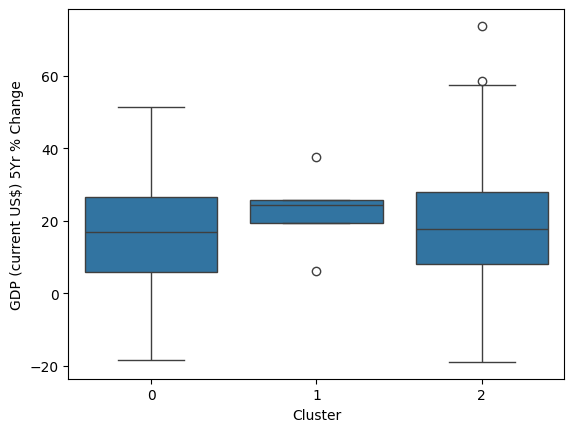

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_selected, x='Cluster', y='GDP (current US$) 5Yr % Change')


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Clusterdbscan', ylabel='GDP (current US$) 5Yr % Change'>

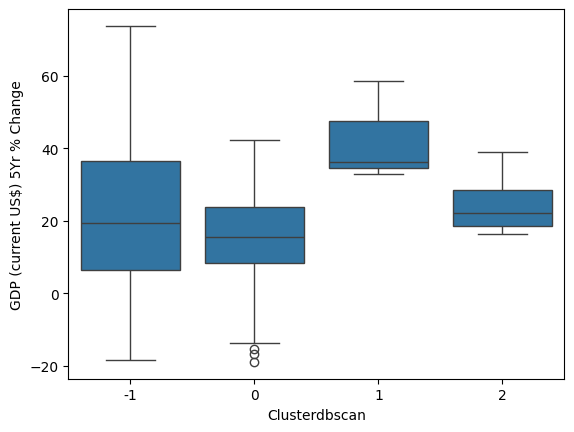

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_selected, x='Clusterdbscan', y='GDP (current US$) 5Yr % Change')


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Clusterdbscan', ylabel='Population Growth Scaled (0-100)'>

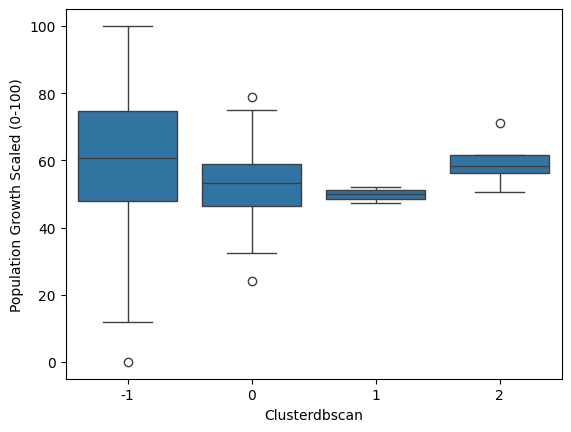

In [ ]:
sns.boxplot(data=df_selected, x='Clusterdbscan', y='Population Growth Scaled (0-100)')


In [ ]:
sns.boxplot(data=df_selected, x='Clusterdbscan', y='Total Function % of GDP')


ValueError: Could not interpret value `Total Function % of GDP` for `y`. An entry with this name does not appear in `data`.

In [ ]:
sns.boxplot(data=df_selected, x='Clusterdbscan', y='Real interest rate (%) 5Yr % Change')


ValueError: Could not interpret value `Real interest rate (%) 5Yr % Change` for `y`. An entry with this name does not appear in `data`.

C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Clusterdbscan', ylabel='Public Social spending % of GDP 5Yr % Change'>

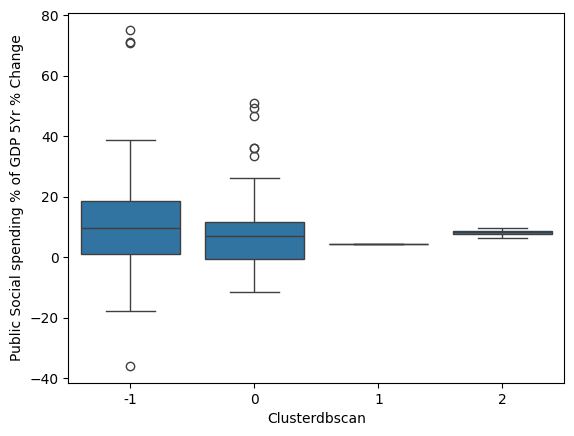

In [ ]:
sns.boxplot(data=df_selected, x='Clusterdbscan', y='Public Social spending % of GDP 5Yr % Change')


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Clusterdbscan', ylabel='Tax revenue (% of GDP) 5Yr % Change'>

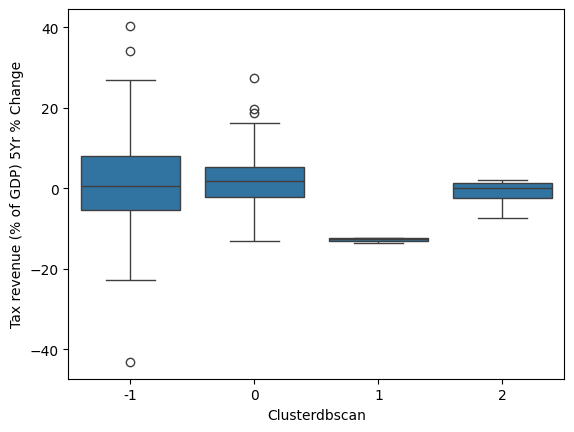

In [ ]:
sns.boxplot(data=df_selected, x='Clusterdbscan', y='Tax revenue (% of GDP) 5Yr % Change')


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Clusterdbscan', ylabel='Central Government Debt (Percent of GDP) 5Yr % Change'>

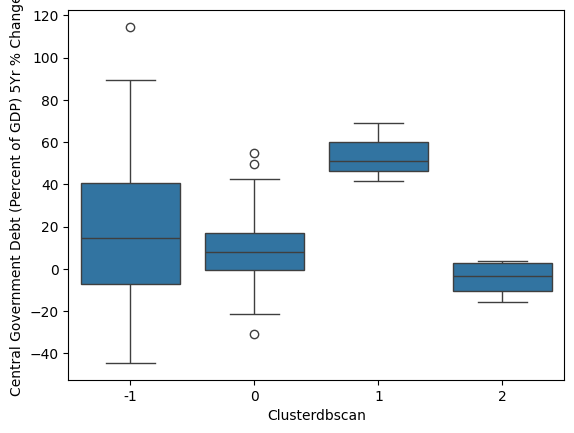

In [ ]:
sns.boxplot(data=df_selected, x='Clusterdbscan', y='Central Government Debt (Percent of GDP) 5Yr % Change')


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Clusterdbscan', ylabel='FDI % of GDP 5Yr % Change'>

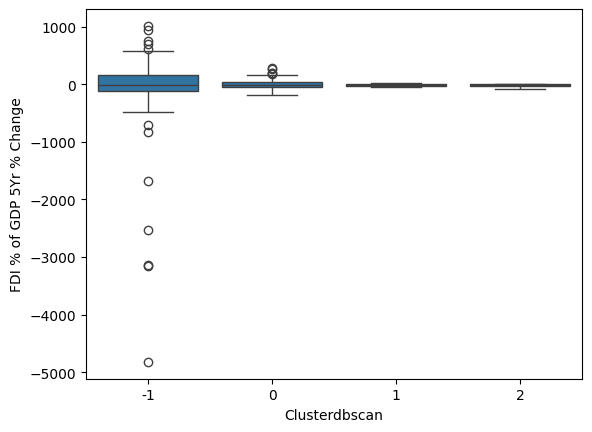

In [ ]:
sns.boxplot(data=df_selected, x='Clusterdbscan', y='FDI % of GDP 5Yr % Change')


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Clusterdbscan', ylabel='Overall Score 5Yr % Change'>

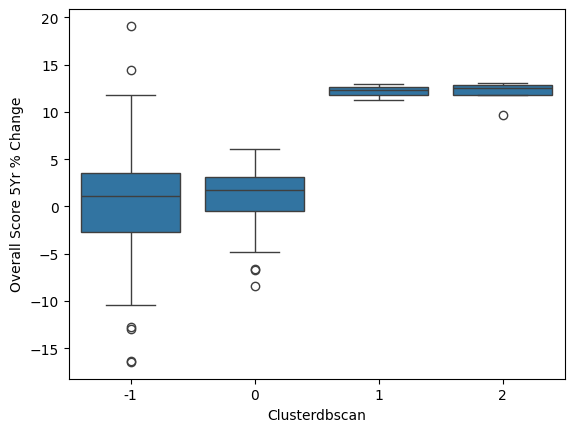

In [ ]:
sns.boxplot(data=df_selected, x='Clusterdbscan', y='Overall Score 5Yr % Change')


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Clusterdbscan', ylabel='Cluster'>

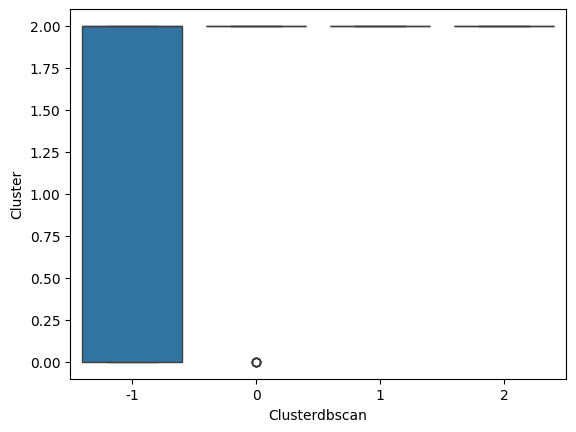

In [ ]:
sns.boxplot(data=df_selected, x='Clusterdbscan', y='Cluster')


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 2023 and exclude rows where "Real interest rate (%)" is 3.43
df_2023_filtered = df[(df["Year"] == 2023) & (df["Real interest rate (%)"] != 3.434751)]

# Sort for better visualization
df_2023_sorted = df_2023_filtered.sort_values("Real interest rate (%)", ascending=True)

# Plot
plt.figure(figsize=(10, len(df_2023_sorted) * 0.3))
sns.barplot(
    x="Real interest rate (%)",
    y="Country Name",
    data=df_2023_sorted,
    palette="coolwarm"
)

# Add value labels
for index, value in enumerate(df_2023_sorted["Real interest rate (%)"]):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.title("Real Interest Rate (%) by Country in 2023 (Excluding 3.43%)")
plt.xlabel("Real Interest Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for year 2023 and drop missing values for that column
df_2023 = df[df["Year"] == 2019].dropna(subset=["Profit tax (% of commercial profits)"])

# Sort values for better readability
df_2023_sorted = df_2023.sort_values(by="Profit tax (% of commercial profits)", ascending=True)

# Plot
plt.figure(figsize=(12, 10))
barplot = sns.barplot(
    data=df_2023_sorted,
    y="Country Name",
    x="Profit tax (% of commercial profits)",
    palette="mako"
)

# Annotate values on bars
for index, row in df_2023_sorted.iterrows():
    plt.text(row["Profit tax (% of commercial profits)"] + 0.5, 
             index, 
             f'{row["Profit tax (% of commercial profits)"]:.1f}', 
             va='center', 
             fontsize=9)

plt.title("Profit Tax (% of Commercial Profits) by Country - 2019", fontsize=16)
plt.xlabel("Profit Tax (% of Commercial Profits)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

